In [18]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 600

cblack = '#262626'
cred = '#FE7070'
cgrey = '#ccc6c7'
cgreen = '#03CEA4' #'#05B9A0'
cpurple = '#8B8EFF'
cyellow = '#FFCC00'
cblue = '#30BCED'

siriusblue = "#2a7de9"
spacecadet = "#171738"
federalblue = "#2E1760"
violet = "#320E3B"
tekhelet = "#4C2A85"

cgd = '#62605c'
corange = '#ff5000'

def pretify_plt(plt):
    # Removing top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.tick_params(axis='both', which='both', length=0, labelcolor=cblack)
    plt.grid(alpha=0.3, linestyle='--')
    
    return plt

def set_colors(ax, color):
    ax.xaxis.label.set_color(color)        #setting up X-axis label color to yellow
    ax.yaxis.label.set_color(color)          #setting up Y-axis label color to blue

    ax.tick_params(axis='x', colors=color)    #setting up X-axis tick color to red
    ax.tick_params(axis='y', colors=color)  #setting up Y-axis tick color to black

    ax.spines['left'].set_color(color)        # setting up Y-axis tick color to red
    ax.spines['top'].set_color(color)

def disable_ax_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def dotted_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.spines['bottom'].set_linewidth(.2)  
    ax.spines['bottom'].set_linestyle((0,(16,16))) 
    ax.spines['right'].set_linewidth(.2)  
    ax.spines['right'].set_linestyle((0,(16,16))) 

def set_xmargin(ax, left=0.0, right=0.3):
    ax.set_xmargin(0)
    ax.autoscale_view()
    lim = ax.get_xlim()
    delta = np.diff(lim)
    left = lim[0] - delta * left
    right = lim[1] + delta * right
    ax.set_xlim(left, right)

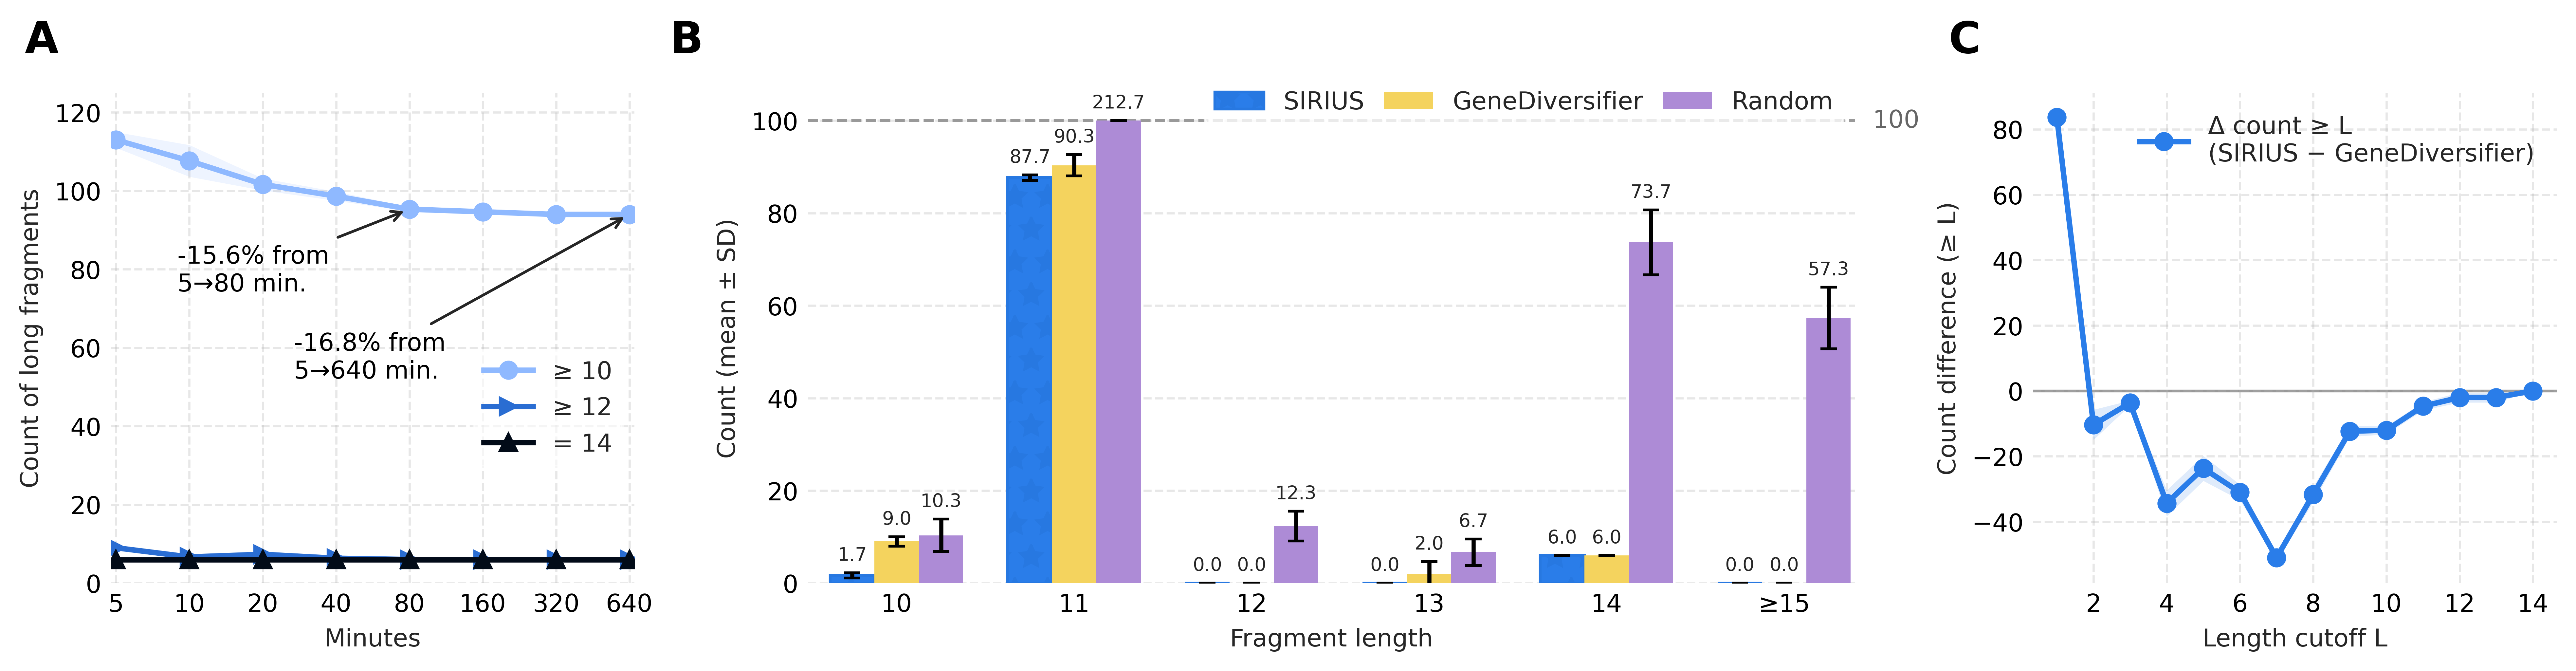

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from collections import defaultdict

plt.rcParams['figure.dpi'] = 600

cutoff_colors = {
    10: "#8fb9ff",
    11: "#5e7bef",
    12: "#2a6dd2",
    13: "#1f1fb6",
    14: "#020B18",
}

# 1×3 layout with middle subplot twice as wide
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(13, 3.3),
    gridspec_kw={'width_ratios': [1, 2, 1]},
    constrained_layout=True
)

fontsize = 9

# =========================
# Panel A — tail counts vs time (mean ± SD) using 3 reps/time
# =========================
srs_paths = [f"times/sirius_out_{i}" for i in range(1, 25)]
times_per_run = [5, 5, 5, 10, 10, 10, 20, 20, 20, 40, 40, 40, 80, 80, 80, 160, 160, 160, 320, 320, 320, 640, 640, 640]
Ks = [10, 12, 14]
markers = {10: "o", 11: "x", 12: ">", 13: "P", 14: "^"}  # used if present

def load_length_counts(path):
    """Parse the first length_counts* file into {length: count}."""
    files = os.listdir(path)
    fname = next(f for f in files if f.startswith("length_counts"))
    counts = {}
    with open(os.path.join(path, fname), "r") as f:
        for line in f:
            if "occurrences" not in line:
                continue
            s = line.split(": ")
            L = int(s[0].split()[1])
            c = int(s[1].split()[0])
            counts[L] = c
    return counts

def count_ge_k(counts, k):
    return sum(c for L, c in counts.items() if L >= k)

# Build {time: [rep1, rep2, rep3]}
times_dict = defaultdict(list)
for path, t in zip(srs_paths, times_per_run):
    times_dict[t].append(load_length_counts(path))

# warn if not 3 reps per time
for t, reps in sorted(times_dict.items()):
    if len(reps) != 3:
        print(f"Warning: time {t} has {len(reps)} replicates, expected 3.")

# mean ± SD per time for each cutoff
times = np.array(sorted(times_dict))
means = {k: [] for k in Ks}
stds  = {k: [] for k in Ks}
for t in times:
    reps = times_dict[t]
    for k in Ks:
        vals = [count_ge_k(r, k) for r in reps]
        means[k].append(np.mean(vals))
        stds[k].append(np.std(vals, ddof=1))

# fallback if cutoff_colors not defined elsewhere (keeps your external palette if present)
try:
    cutoff_colors
except NameError:
    from matplotlib.cm import get_cmap
    from matplotlib.colors import to_hex
    cmap = get_cmap("plasma")
    cutoff_colors = {k: to_hex(cmap(i/(len(Ks)-1))) for i, k in enumerate(Ks)}

for k in Ks:
    m = np.array(means[k]); s = np.array(stds[k])
    label = f"≥ {k}"

    if k == 14:
        label = f"= {k}"

    ax1.plot(times, m, marker=markers[k], lw=2, color=cutoff_colors[k], label=label)
    ax1.fill_between(times, m-s, m+s, color=cutoff_colors[k], alpha=0.15, linewidth=0)


ax1.set_xlabel('Minutes', fontsize=fontsize, color=cblack)
ax1.set_ylabel('Count of long fragments', fontsize=fontsize, color=cblack)

# log2 x-axis so 5,10,20,40,80,... are evenly spaced
ax1.set_xscale('log', base=2)
f = 2**0.07  # ~7% padding
ax1.set_xlim(times[0]/f, times[-1]*f)
ax1.set_ylim(0, 125)

ax1.set_xticks(times)
ax1.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v)}"))

ax1.grid(alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', which='both', length=0, labelsize=fontsize)
disable_ax_spines(ax1)
ax1.legend(labelcolor=cblack, fontsize=fontsize, loc='best', bbox_to_anchor=(0.5, 0., 0.5, 0.5), edgecolor='white', framealpha=0.6)

m10 = np.array(means[10])
pct = 100*(m10[-1]-m10[0])/m10[0]
ax1.annotate(f"{pct:.1f}% from\n5→640 min.",
             xy=(times[-1], m10[-1]), xytext=(-123, -60),
             textcoords="offset points", arrowprops=dict(arrowstyle='->', lw=1, color=cblack),
             fontsize=9)

pct = 100*(m10[4]-m10[0])/m10[0]
ax1.annotate(f"{pct:.1f}% from\n5→80 min.",
             xy=(times[4], m10[4]), xytext=(-85, -30),
             textcoords="offset points", arrowprops=dict(arrowstyle='->', lw=1, color=cblack),
             fontsize=9)

# =========================
# Panel B — bars (mean +/- SD) for SIRIUS, GD, Random
# =========================
thresholds = [10, 11, 12, 13, 14, 15]  # 15 = tail bin (≥15)
group_w    = 0.25
cap_y      = 100
headroom   = 6

sirius_inputs = [
    "SRS/mCitrine/length_counts_2025-11-04_17-24-56.txt",
    "SRS/mCitrine_1/length_counts_2025-11-04_18-45-31.txt",
    "SRS/mCitrine_2/length_counts_2025-11-04_20-06-08.txt"
]
gd_inputs = [
    "GD/gd_output_mCitrine_1.txt",
    "GD/gd_output_mCitrine_2.txt",
    "GD/gd_output_mCitrine_3.txt",
]
random_inputs = [
    "RANDOM/random_mCitrine_1.txt",
    "RANDOM/random_mCitrine_2.txt",
    "RANDOM/random_mCitrine_3.txt",
]

def load_length_counts_file(path):
    counts = {}
    with open(path, "r") as f:
        for line in f:
            if "occurrences" not in line:
                continue
            s = line.split(": ")
            L = int(s[0].split()[1])
            c = int(s[1].split()[0])
            counts[L] = c
    return counts

def load_reps(files):
    return [load_length_counts_file(fp) for fp in files]

def exact_or_tail_value(counts, k):
    return sum(v for L, v in counts.items() if L >= 15) if k == 15 else counts.get(k, 0)

def mean_std_for_threshold(reps, k):
    vals = [exact_or_tail_value(r, k) for r in reps]
    return float(np.mean(vals)), (float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0)

def clip_err_top(means, stds, cap):
    means = np.asarray(means, float)
    stds  = np.asarray(stds,  float)
    tops  = means + stds
    m_clip = np.minimum(means, cap)
    s_clip = np.maximum(0.0, np.minimum(stds, cap - m_clip))
    return m_clip, s_clip, tops

def annotate_bars_above_cap(ax, bars, true_means, true_tops, cap,
                            fmt="{:.1f}", pad_pts=3, fontsize=9, color="black"):
    for rect, m, top in zip(bars, true_means, true_tops):
        x = rect.get_x() + rect.get_width()/2.0
        y = cap if top > cap else top
        ax.annotate(fmt.format(m), xy=(x, y), xytext=(0, pad_pts),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=fontsize, color=color, clip_on=False, zorder=5)

# load reps
srs_reps = load_reps(sirius_inputs)
gd_reps  = load_reps(gd_inputs)
rnd_reps = load_reps(random_inputs)

# mean±SD for each method
methods = {"SIRIUS": srs_reps, "GeneDiversifier": gd_reps, "Random": rnd_reps}
means_m, stds_m = {}, {}
for name, reps in methods.items():
    m_list, s_list = [], []
    for k in thresholds:
        m, s = mean_std_for_threshold(reps, k)
        m_list.append(m); s_list.append(s)
    means_m[name] = np.array(m_list)
    stds_m[name]  = np.array(s_list)

xpos = np.arange(len(thresholds))

# bars
m_s, s_s, top_s = clip_err_top(means_m["SIRIUS"],          stds_m["SIRIUS"],          cap_y)
m_g, s_g, top_g = clip_err_top(means_m["GeneDiversifier"], stds_m["GeneDiversifier"], cap_y)
m_r, s_r, top_r = clip_err_top(means_m["Random"],          stds_m["Random"],          cap_y)

b_s = ax2.bar(xpos - group_w, m_s, group_w, yerr=s_s, capsize=3,
              label="SIRIUS", facecolor="#2a7de9", edgecolor="#2778e1", hatch='*', zorder=3)

b_g = ax2.bar(xpos,           m_g, group_w, yerr=s_g, capsize=3,
              label="GeneDiversifier", facecolor="#F4D35E", zorder=3)

b_r = ax2.bar(xpos + group_w, m_r, group_w, yerr=s_r, capsize=3,
              label="Random", facecolor="#AD8BD6", zorder=3)

# cap line at 100
ax2.axhline(cap_y, color='#999999', linewidth=1.0, linestyle='--', zorder=2)
ax2.text(xpos[-1] + 0.5, cap_y, "100", va="center", ha="left", fontsize=fontsize, color="#666666")

# labels
annotate_bars_above_cap(ax2, b_s, means_m["SIRIUS"],          m_s + s_s, cap_y, fmt="{:.1f}", fontsize=fontsize-2.2, color=cblack)
annotate_bars_above_cap(ax2, b_g, means_m["GeneDiversifier"], m_g + s_g, cap_y, fmt="{:.1f}", fontsize=fontsize-2.2, color=cblack)
annotate_bars_above_cap(ax2, b_r, means_m["Random"],          m_r + s_r, cap_y, fmt="{:.1f}", fontsize=fontsize-2.2, color=cblack)

# ticks/labels
ax2.set_xticks(xpos)
ax2.set_xticklabels([str(k) if k < 15 else "≥15" for k in thresholds])
ax2.set_xlim(xpos[0] - 2.0*group_w, xpos[-1] + 1.6*group_w)
ax2.set_ylim(0, cap_y + headroom)
ax2.set_xlabel("Fragment length", color=cblack, fontsize=fontsize)
ax2.set_ylabel("Count (mean ± SD)", color=cblack, fontsize=fontsize)
ax2.grid(alpha=0.3, linestyle='--', axis='y')
ax2.tick_params(axis='both', which='both', length=0, labelsize=fontsize)
ax2.legend(labelcolor=cblack, edgecolor='white', columnspacing=0.8, framealpha=0.8, ncols=3, fontsize=fontsize, loc='best', bbox_to_anchor=(0, 0.05, 1, 1))
disable_ax_spines(ax2)

# =========================
# Panel C — Δ tail counts ≥L (replicate means with SD band)
# =========================
def tail_vec(counts, Ls):
    arr = np.array([counts.get(L, 0) for L in Ls], dtype=float)
    return arr[::-1].cumsum()[::-1]

# reuse srs_reps, gd_reps from above
Ls_max = max(
    max((max(r.keys()) for r in srs_reps), default=1),
    max((max(r.keys()) for r in gd_reps ), default=1)
)
Ls = np.arange(1, Ls_max + 1, dtype=int)

tail_s = np.vstack([tail_vec(r, Ls) for r in srs_reps])
tail_g = np.vstack([tail_vec(r, Ls) for r in gd_reps])

mean_s = tail_s.mean(axis=0);
std_s = tail_s.std(axis=0, ddof=1) if tail_s.shape[0] > 1 else np.zeros_like(Ls, float)

mean_g = tail_g.mean(axis=0);
std_g = tail_g.std(axis=0, ddof=1) if tail_g.shape[0] > 1 else np.zeros_like(Ls, float)

n_s, n_g = tail_s.shape[0], tail_g.shape[0]
delta_mean = mean_s - mean_g
sd_delta   = np.sqrt((std_s**2)/max(1, n_s) + (std_g**2)/max(1, n_g))

ax3.axhline(0, color='0.6', lw=1, zorder=1)
ax3.plot(Ls, delta_mean, marker='o', lw=2, color=siriusblue, label='Δ count ≥ L\n(SIRIUS − GeneDiversifier)', zorder=3)
ax3.fill_between(Ls, delta_mean - sd_delta, delta_mean + sd_delta,
                 color=siriusblue, alpha=0.15, zorder=2, linewidth=0)

ax3.set_xticks(np.arange(2, Ls_max + 1, 2))
ax3.set_xlabel('Length cutoff L', color=cblack, fontsize=fontsize)
ax3.set_ylabel('Count difference (≥ L)', color=cblack, fontsize=fontsize)
ax3.grid(alpha=0.3, linestyle='--')
ax3.tick_params(axis='both', which='both', length=0, labelsize=fontsize)
ax3.legend(labelcolor=cblack, frameon=False, fontsize=fontsize)
disable_ax_spines(ax3)

# Panel labels
ax1.text(-0.1, 1.15, 'A', transform=ax1.transAxes, fontsize=16, va='top', ha='right', fontweight='bold')
ax2.text(-0.1, 1.15, 'B', transform=ax2.transAxes, fontsize=16, va='top', ha='right', fontweight='bold')
ax3.text(-0.1, 1.15, 'C', transform=ax3.transAxes, fontsize=16, va='top', ha='right', fontweight='bold')

plt.savefig("fig2.pdf", bbox_inches='tight')

In [20]:
delta_mean

array([ 83.66666667, -10.33333333,  -3.66666667, -34.33333333,
       -23.66666667, -31.        , -51.        , -31.66666667,
       -12.33333333, -12.        ,  -4.66666667,  -2.        ,
        -2.        ,   0.        ])

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from collections import defaultdict

plt.rcParams['figure.dpi'] = 600

def load_length_counts_file(path):
    counts = {}
    with open(path, "r") as f:
        for line in f:
            if "occurrences" not in line:
                continue
            s = line.split(": ")
            L = int(s[0].split()[1])
            c = int(s[1].split()[0])
            counts[L] = c
    return counts

def load_reps(files):
    return [load_length_counts_file(fp) for fp in files]

def exact_or_tail_value(counts, k, last_one):
    return sum(v for L, v in counts.items() if L >= last_one) if k == last_one else counts.get(k, 0)

def mean_std_for_threshold(reps, k, last_one):
    vals = [exact_or_tail_value(r, k, last_one) for r in reps]
    return float(np.mean(vals)), (float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0)

def clip_err_top(means, stds, cap):
    means = np.asarray(means, float)
    stds  = np.asarray(stds,  float)
    tops  = means + stds
    m_clip = np.minimum(means, cap)
    s_clip = np.maximum(0.0, np.minimum(stds, cap - m_clip))
    return m_clip, s_clip, tops

def annotate_bars_above_cap(ax, bars, true_means, true_tops, cap,
                            fmt="{:.1f}", pad_pts=3, fontsize=9, color="black"):
    for rect, m, top in zip(bars, true_means, true_tops):
        x = rect.get_x() + rect.get_width()/2.0
        y = cap if top > cap else top
        ax.annotate(fmt.format(m), xy=(x, y), xytext=(0, pad_pts),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=fontsize, color=color, clip_on=False, zorder=5)

def paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, anot_fontsize, plt_name):

    cutoff_colors = {
        10: "#8fb9ff",
        11: "#5e7bef",
        12: "#2a6dd2",
        13: "#1f1fb6",
        14: "#020B18",
    }

    # 1×3 layout with middle subplot twice as wide
    fig, (ax2) = plt.subplots(
        1, 1, figsize=(6, 4.3),
    )

    fontsize = 9

    group_w    = 0.25
    cap_y      = 100
    headroom   = 6

    # load reps
    srs_reps = load_reps(sirius_inputs)
    gd_reps  = load_reps(gd_inputs)
    rnd_reps = load_reps(random_inputs)

    # mean±SD for each method
    methods = {"SIRIUS": srs_reps, "GeneDiversifier": gd_reps, "Random": rnd_reps}
    means_m, stds_m = {}, {}
    for name, reps in methods.items():
        m_list, s_list = [], []
        for k in thresholds:
            m, s = mean_std_for_threshold(reps, k, thresholds[-1])
            m_list.append(m); s_list.append(s)
        means_m[name] = np.array(m_list)
        stds_m[name]  = np.array(s_list)

    xpos = np.arange(len(thresholds))

    # bars
    m_s, s_s, top_s = clip_err_top(means_m["SIRIUS"],          stds_m["SIRIUS"],          cap_y)
    m_g, s_g, top_g = clip_err_top(means_m["GeneDiversifier"], stds_m["GeneDiversifier"], cap_y)
    m_r, s_r, top_r = clip_err_top(means_m["Random"],          stds_m["Random"],          cap_y)

    b_s = ax2.bar(xpos - group_w, m_s, group_w, yerr=s_s, capsize=3,
                label="SIRIUS", facecolor="#2a7de9", edgecolor="#2778e1", hatch='*', zorder=3)

    b_g = ax2.bar(xpos,           m_g, group_w, yerr=s_g, capsize=3,
                label="GeneDiversifier", facecolor="#F4D35E", zorder=3)

    b_r = ax2.bar(xpos + group_w, m_r, group_w, yerr=s_r, capsize=3,
                label="Random", facecolor="#AD8BD6", zorder=3)

    # cap line at 100
    ax2.axhline(cap_y, color='#999999', linewidth=1.0, linestyle='--', zorder=2)
    ax2.text(xpos[-1] + 0.5, cap_y, "100", va="center", ha="left", fontsize=fontsize, color="#666666")

    # labels
    annotate_bars_above_cap(ax2, b_s, means_m["SIRIUS"],          m_s + s_s, cap_y, fmt="{:.1f}", fontsize=anot_fontsize, color=cblack)
    annotate_bars_above_cap(ax2, b_g, means_m["GeneDiversifier"], m_g + s_g, cap_y, fmt="{:.1f}", fontsize=anot_fontsize, color=cblack)
    annotate_bars_above_cap(ax2, b_r, means_m["Random"],          m_r + s_r, cap_y, fmt="{:.1f}", fontsize=anot_fontsize, color=cblack)

    # ticks/labels
    ax2.set_xticks(xpos)
    ax2.set_xticklabels([str(k) if k < thresholds[-1] else f"≥{str(thresholds[-1])}" for k in thresholds])
    ax2.set_xlim(xpos[0] - 2.0*group_w, xpos[-1] + 1.6*group_w)
    ax2.set_ylim(0, cap_y + headroom)
    ax2.set_xlabel("Fragment length", color=cblack, fontsize=fontsize)
    ax2.set_ylabel("Count (mean ± SD)", color=cblack, fontsize=fontsize)
    ax2.grid(alpha=0.3, linestyle='--', axis='y')
    ax2.tick_params(axis='both', which='both', length=0, labelsize=fontsize)
    ax2.legend(labelcolor=cblack, edgecolor='white',
               columnspacing=0.8, framealpha=0.8, ncols=3,
                 fontsize=fontsize, loc='best', bbox_to_anchor=(0, 0.05, 1.04, 1.02))
    disable_ax_spines(ax2)
    plt.savefig(f"{plt_name}.pdf", bbox_inches='tight')
    

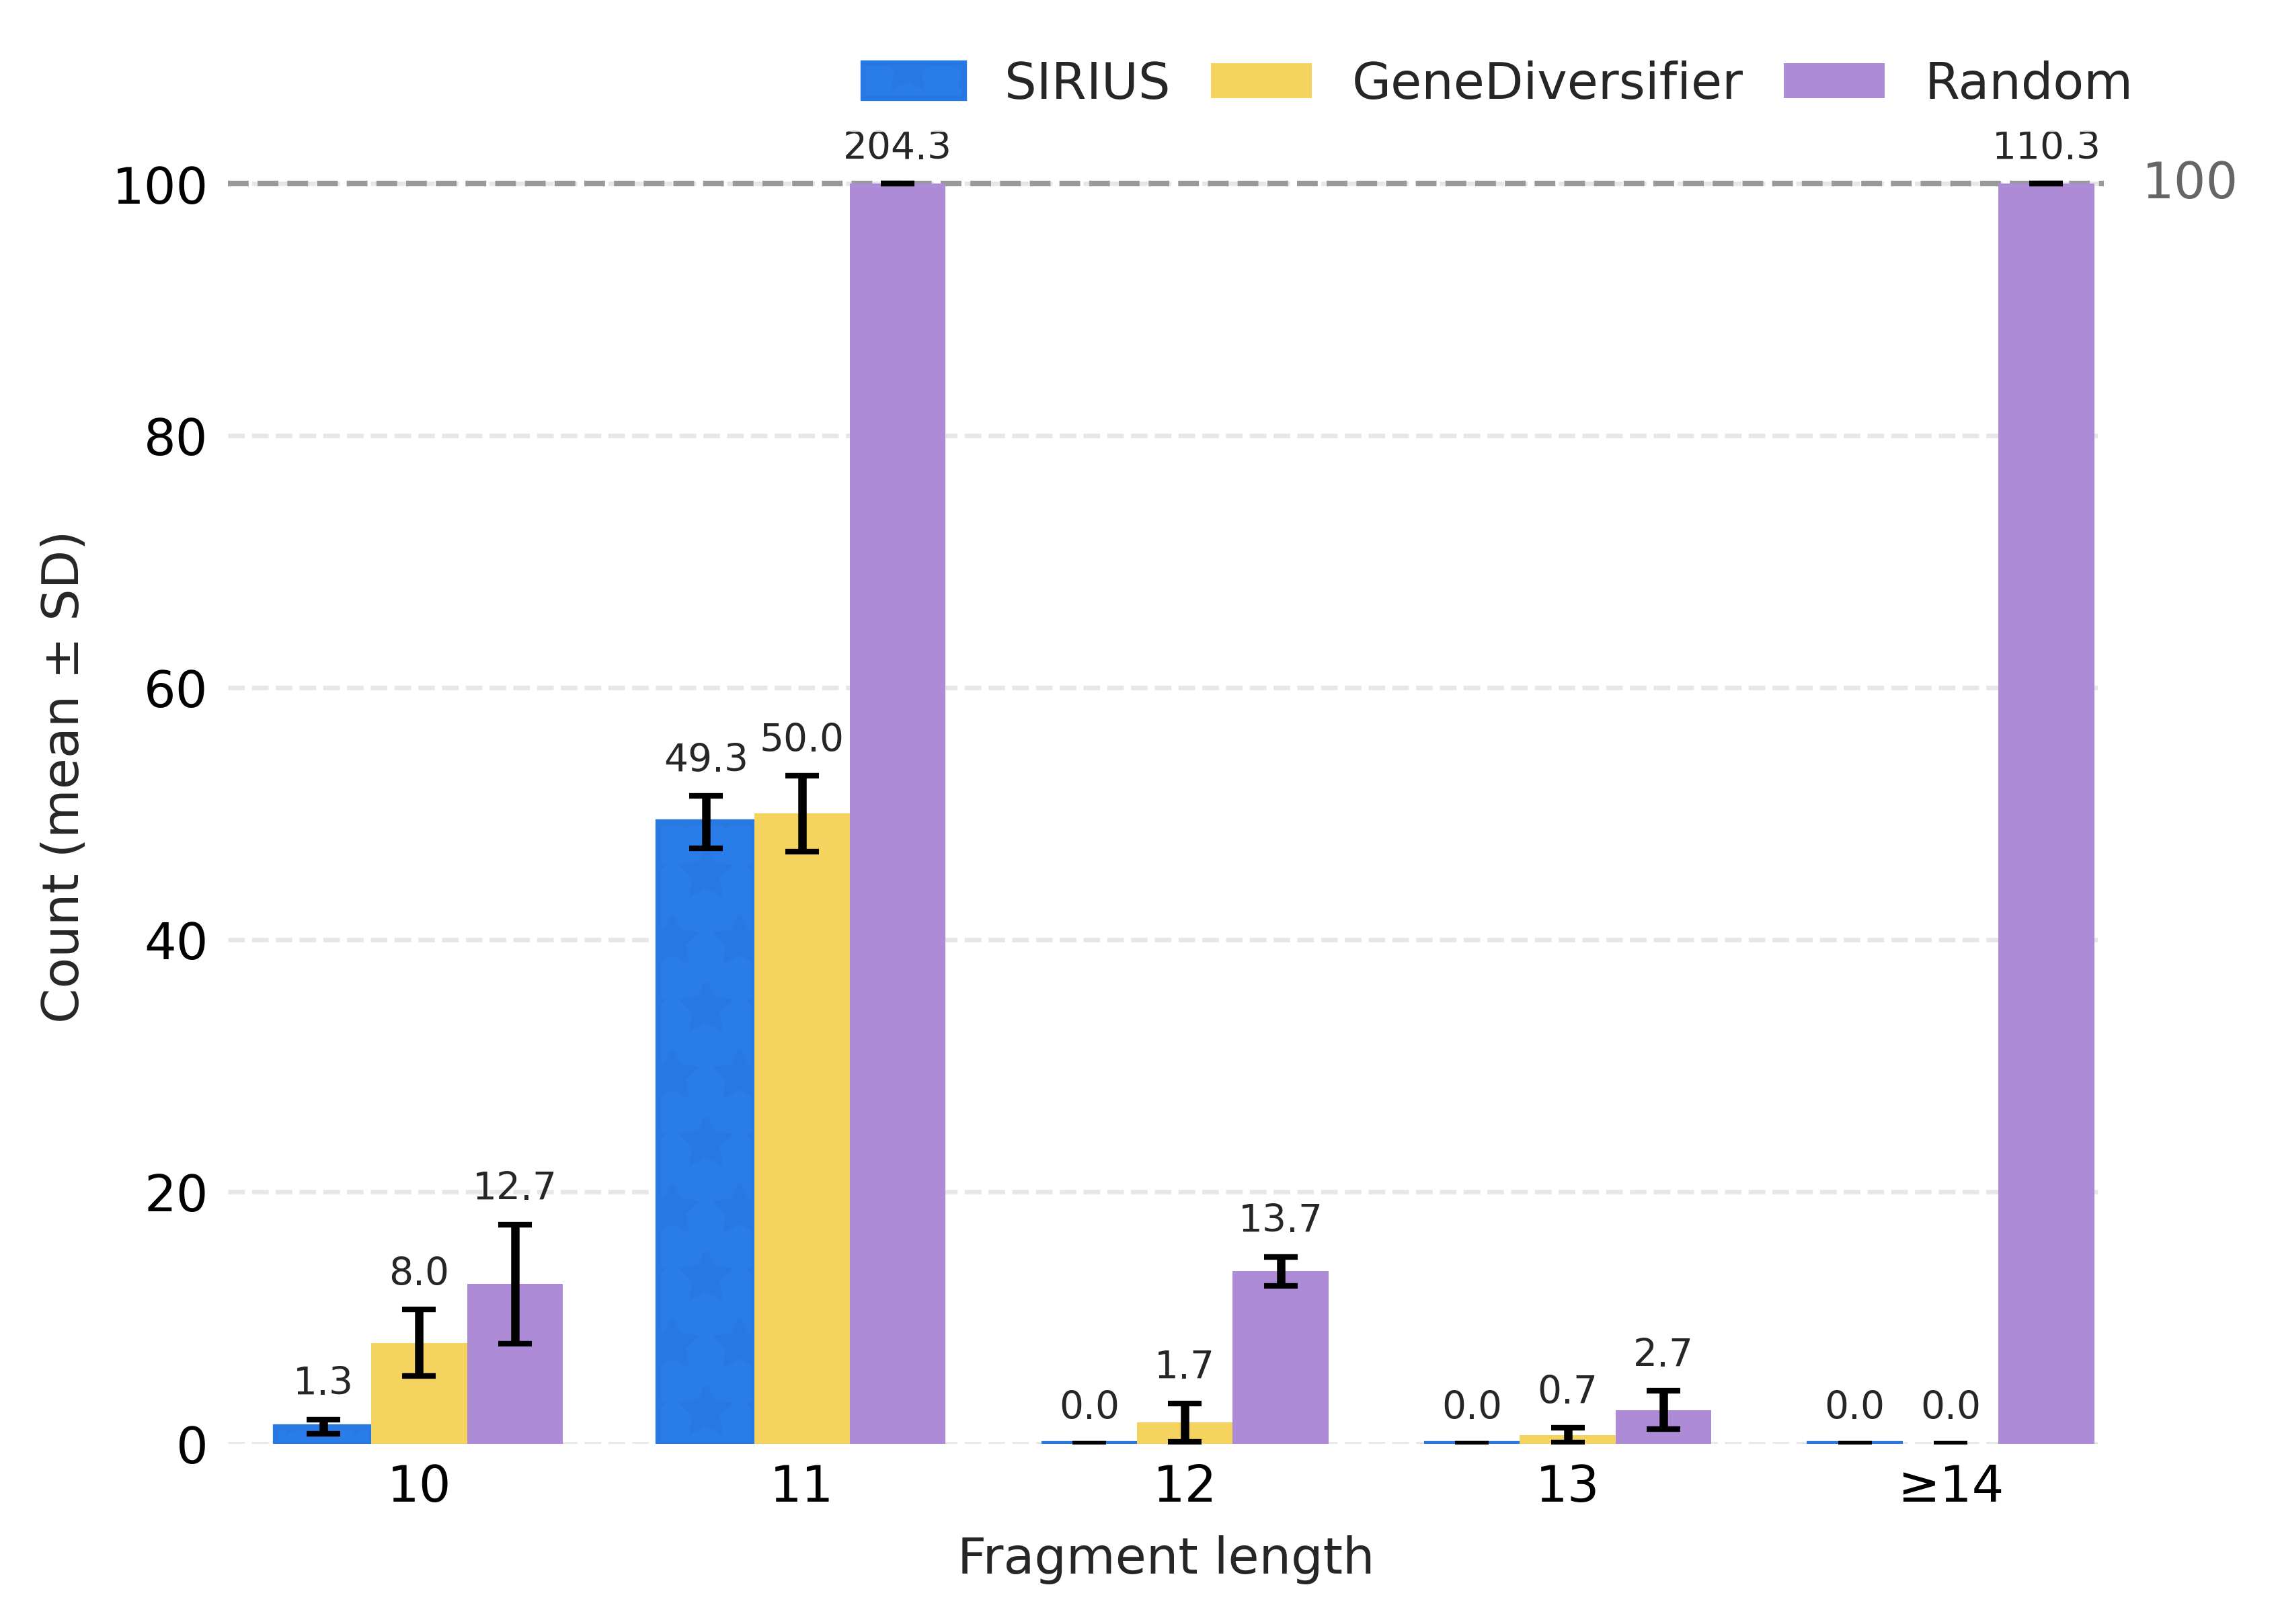

In [22]:
sirius_inputs = [
    "SRS/CALB/length_counts_2025-11-04_13-23-02.txt",
    "SRS/CALB_1/length_counts_2025-11-04_14-43-40.txt",
    "SRS/CALB_2/length_counts_2025-11-04_16-04-17.txt"
]
gd_inputs = [
    "GD/gd_output_CALB_1.txt",
    "GD/gd_output_CALB_2.txt",
    "GD/gd_output_CALB_3.txt",
]
random_inputs = [
    "RANDOM/random_CALB_1.txt",
    "RANDOM/random_CALB_2.txt",
    "RANDOM/random_CALB_3.txt",
]

thresholds = [10, 11, 12, 13, 14]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 6.8, "CALB")

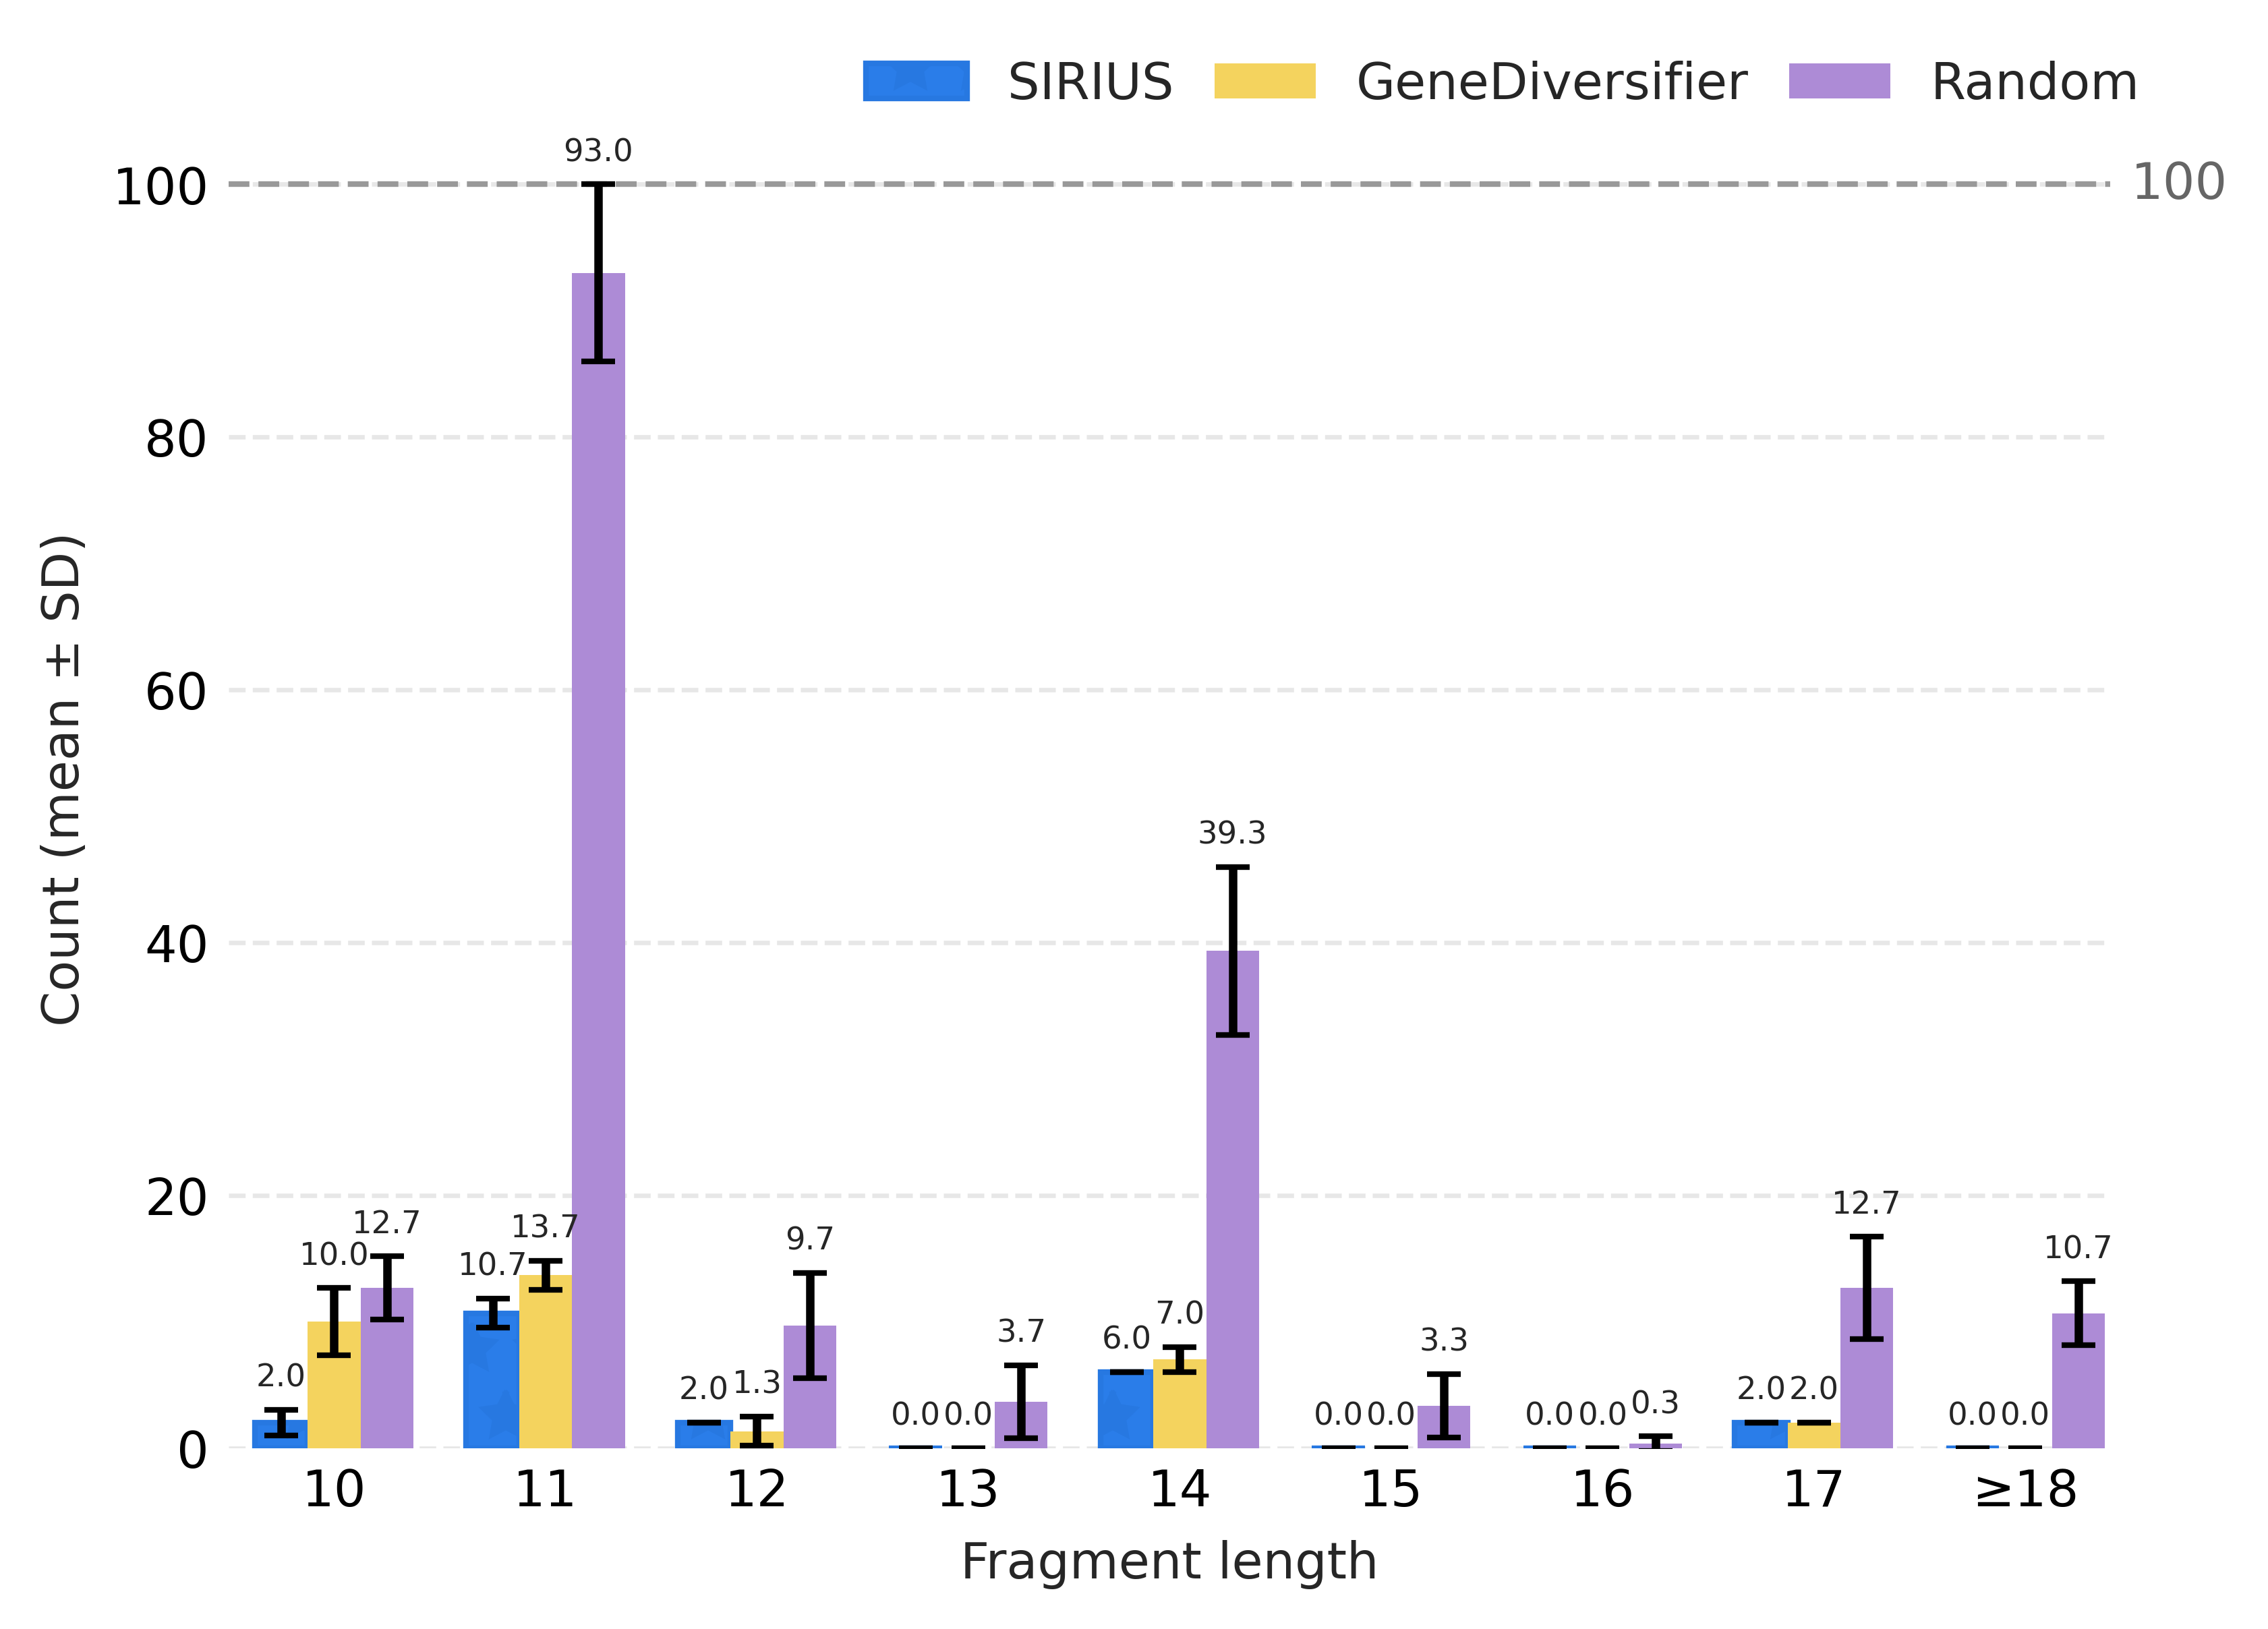

In [23]:
sirius_inputs = [
    "SRS/CSF3/length_counts_2025-11-03_21-17-37.txt",
    "SRS/CSF3_1/length_counts_2025-11-03_22-38-15.txt",
    "SRS/CSF3_2/length_counts_2025-11-03_23-58-51.txt"
]
gd_inputs = [
    "GD/gd_output_CSF3_1.txt",
    "GD/gd_output_CSF3_2.txt",
    "GD/gd_output_CSF3_3.txt",
]
random_inputs = [
    "RANDOM/random_CSF3_1.txt",
    "RANDOM/random_CSF3_2.txt",
    "RANDOM/random_CSF3_3.txt",
]

thresholds = [10, 11, 12, 13, 14, 15, 16, 17, 18]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 5.6, "CSF3")

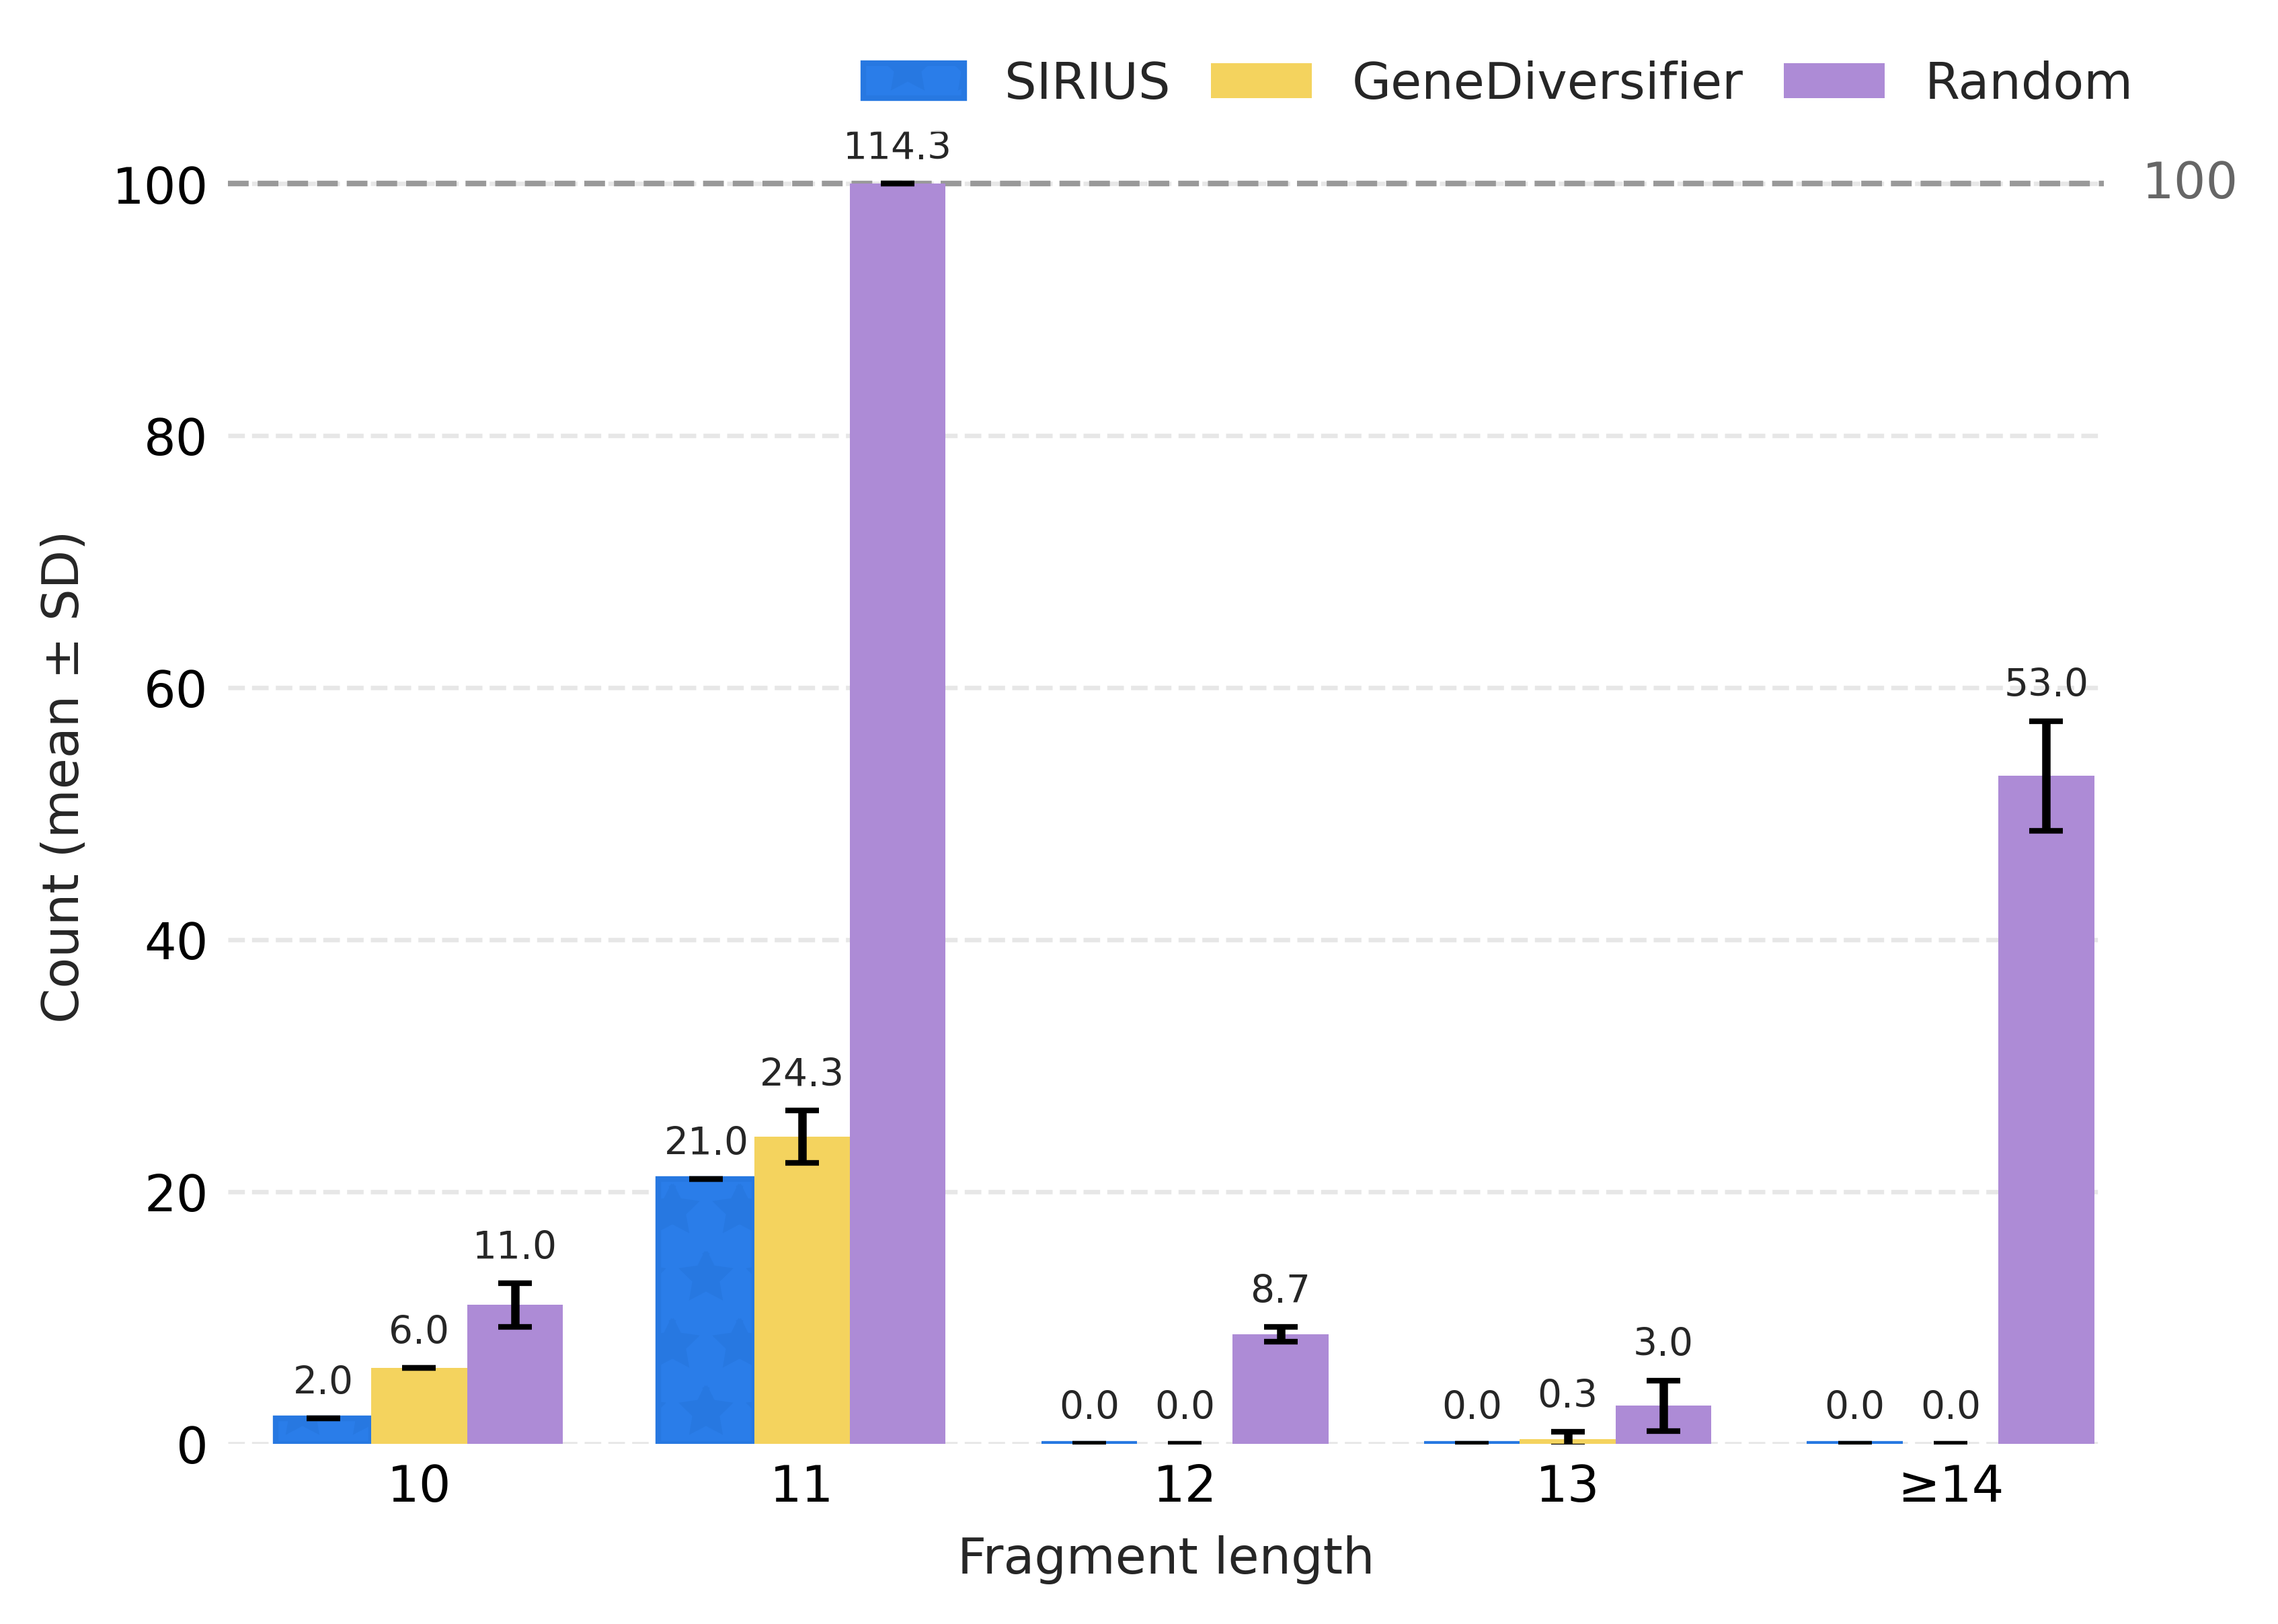

In [24]:
sirius_inputs = [
    "SRS/EPO/length_counts_2025-11-04_01-19-14.txt",
    "SRS/EPO_1/length_counts_2025-11-04_02-39-38.txt",
    "SRS/EPO_2/length_counts_2025-11-04_04-00-05.txt"
]
gd_inputs = [
    "GD/gd_output_EPO_1.txt",
    "GD/gd_output_EPO_2.txt",
    "GD/gd_output_EPO_3.txt",
]
random_inputs = [
    "RANDOM/random_EPO_1.txt",
    "RANDOM/random_EPO_2.txt",
    "RANDOM/random_EPO_3.txt",
]

thresholds = [10, 11, 12, 13, 14]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 6.8, "EPO")

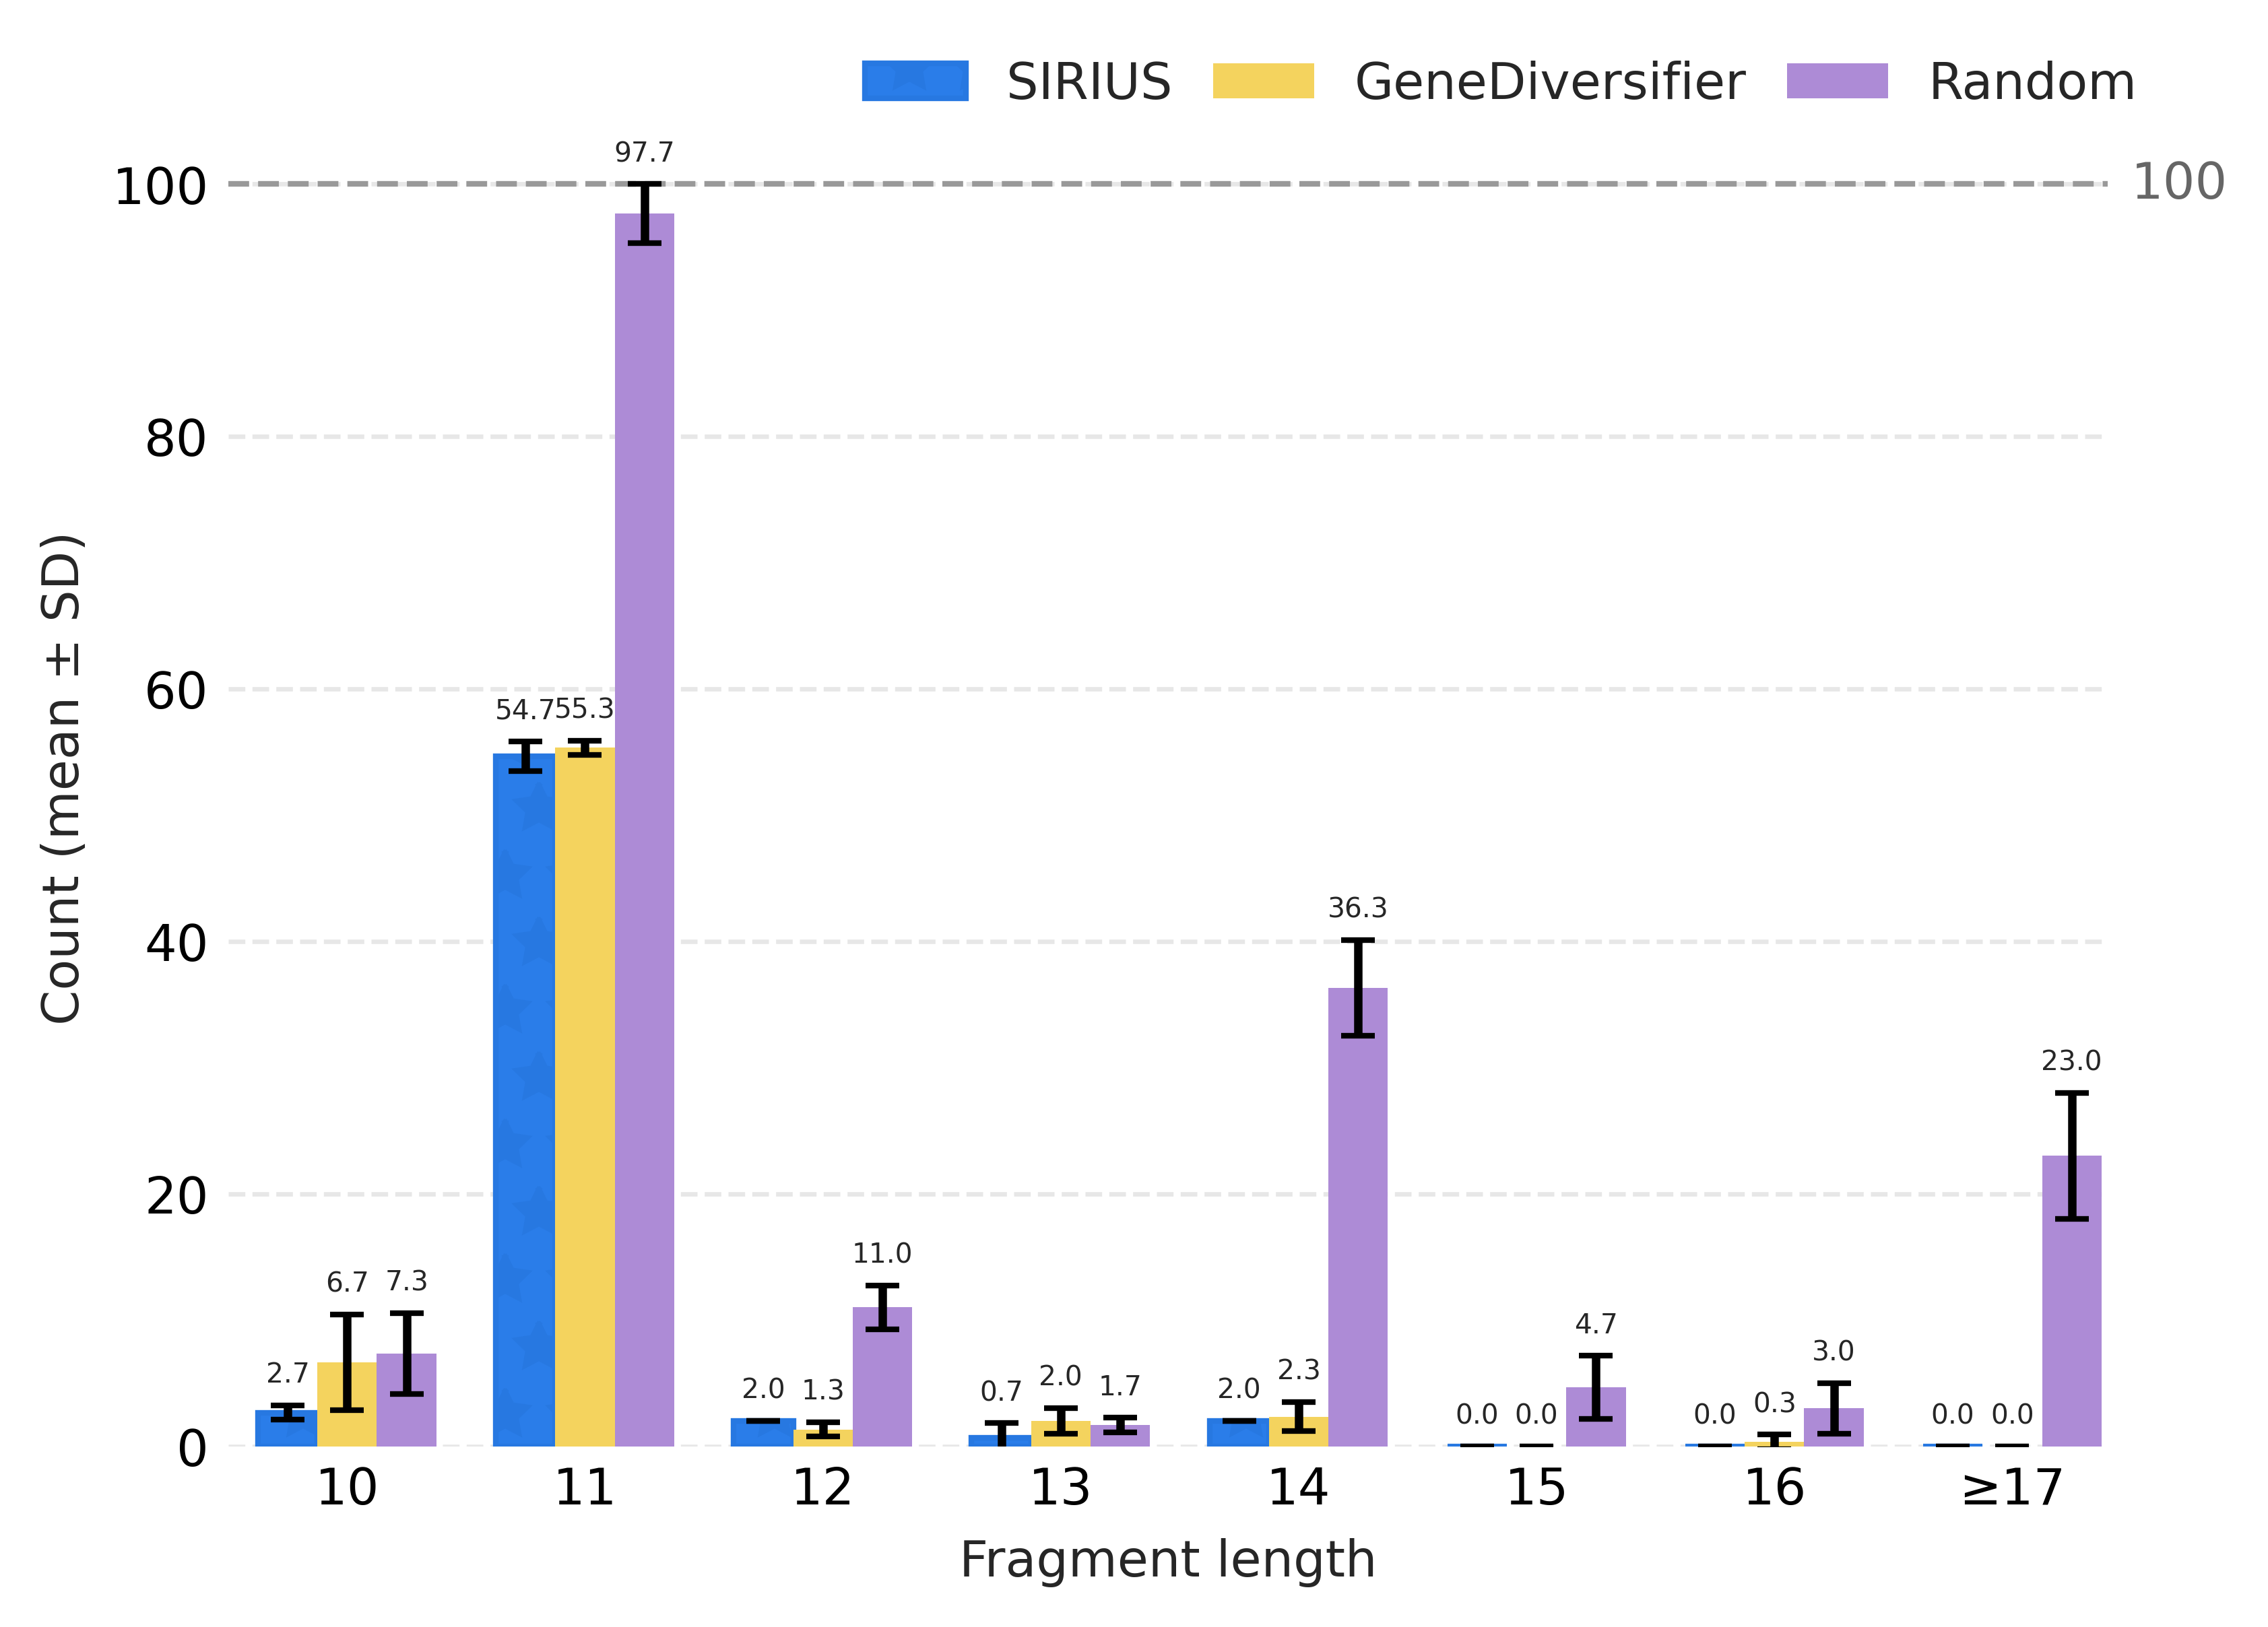

In [25]:
sirius_inputs = [
    "SRS/IGF1/length_counts_2025-11-04_09-21-39.txt",
    "SRS/IGF1_1/length_counts_2025-11-04_10-42-06.txt",
    "SRS/IGF1_2/length_counts_2025-11-04_12-02-28.txt"
]
gd_inputs = [
    "GD/gd_output_IGF1_1.txt",
    "GD/gd_output_IGF1_2.txt",
    "GD/gd_output_IGF1_3.txt",
]
random_inputs = [
    "RANDOM/random_IGF1_1.txt",
    "RANDOM/random_IGF1_2.txt",
    "RANDOM/random_IGF1_3.txt",
]

thresholds = [10, 11, 12, 13, 14, 15, 16, 17]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 4.9, "IGF1")

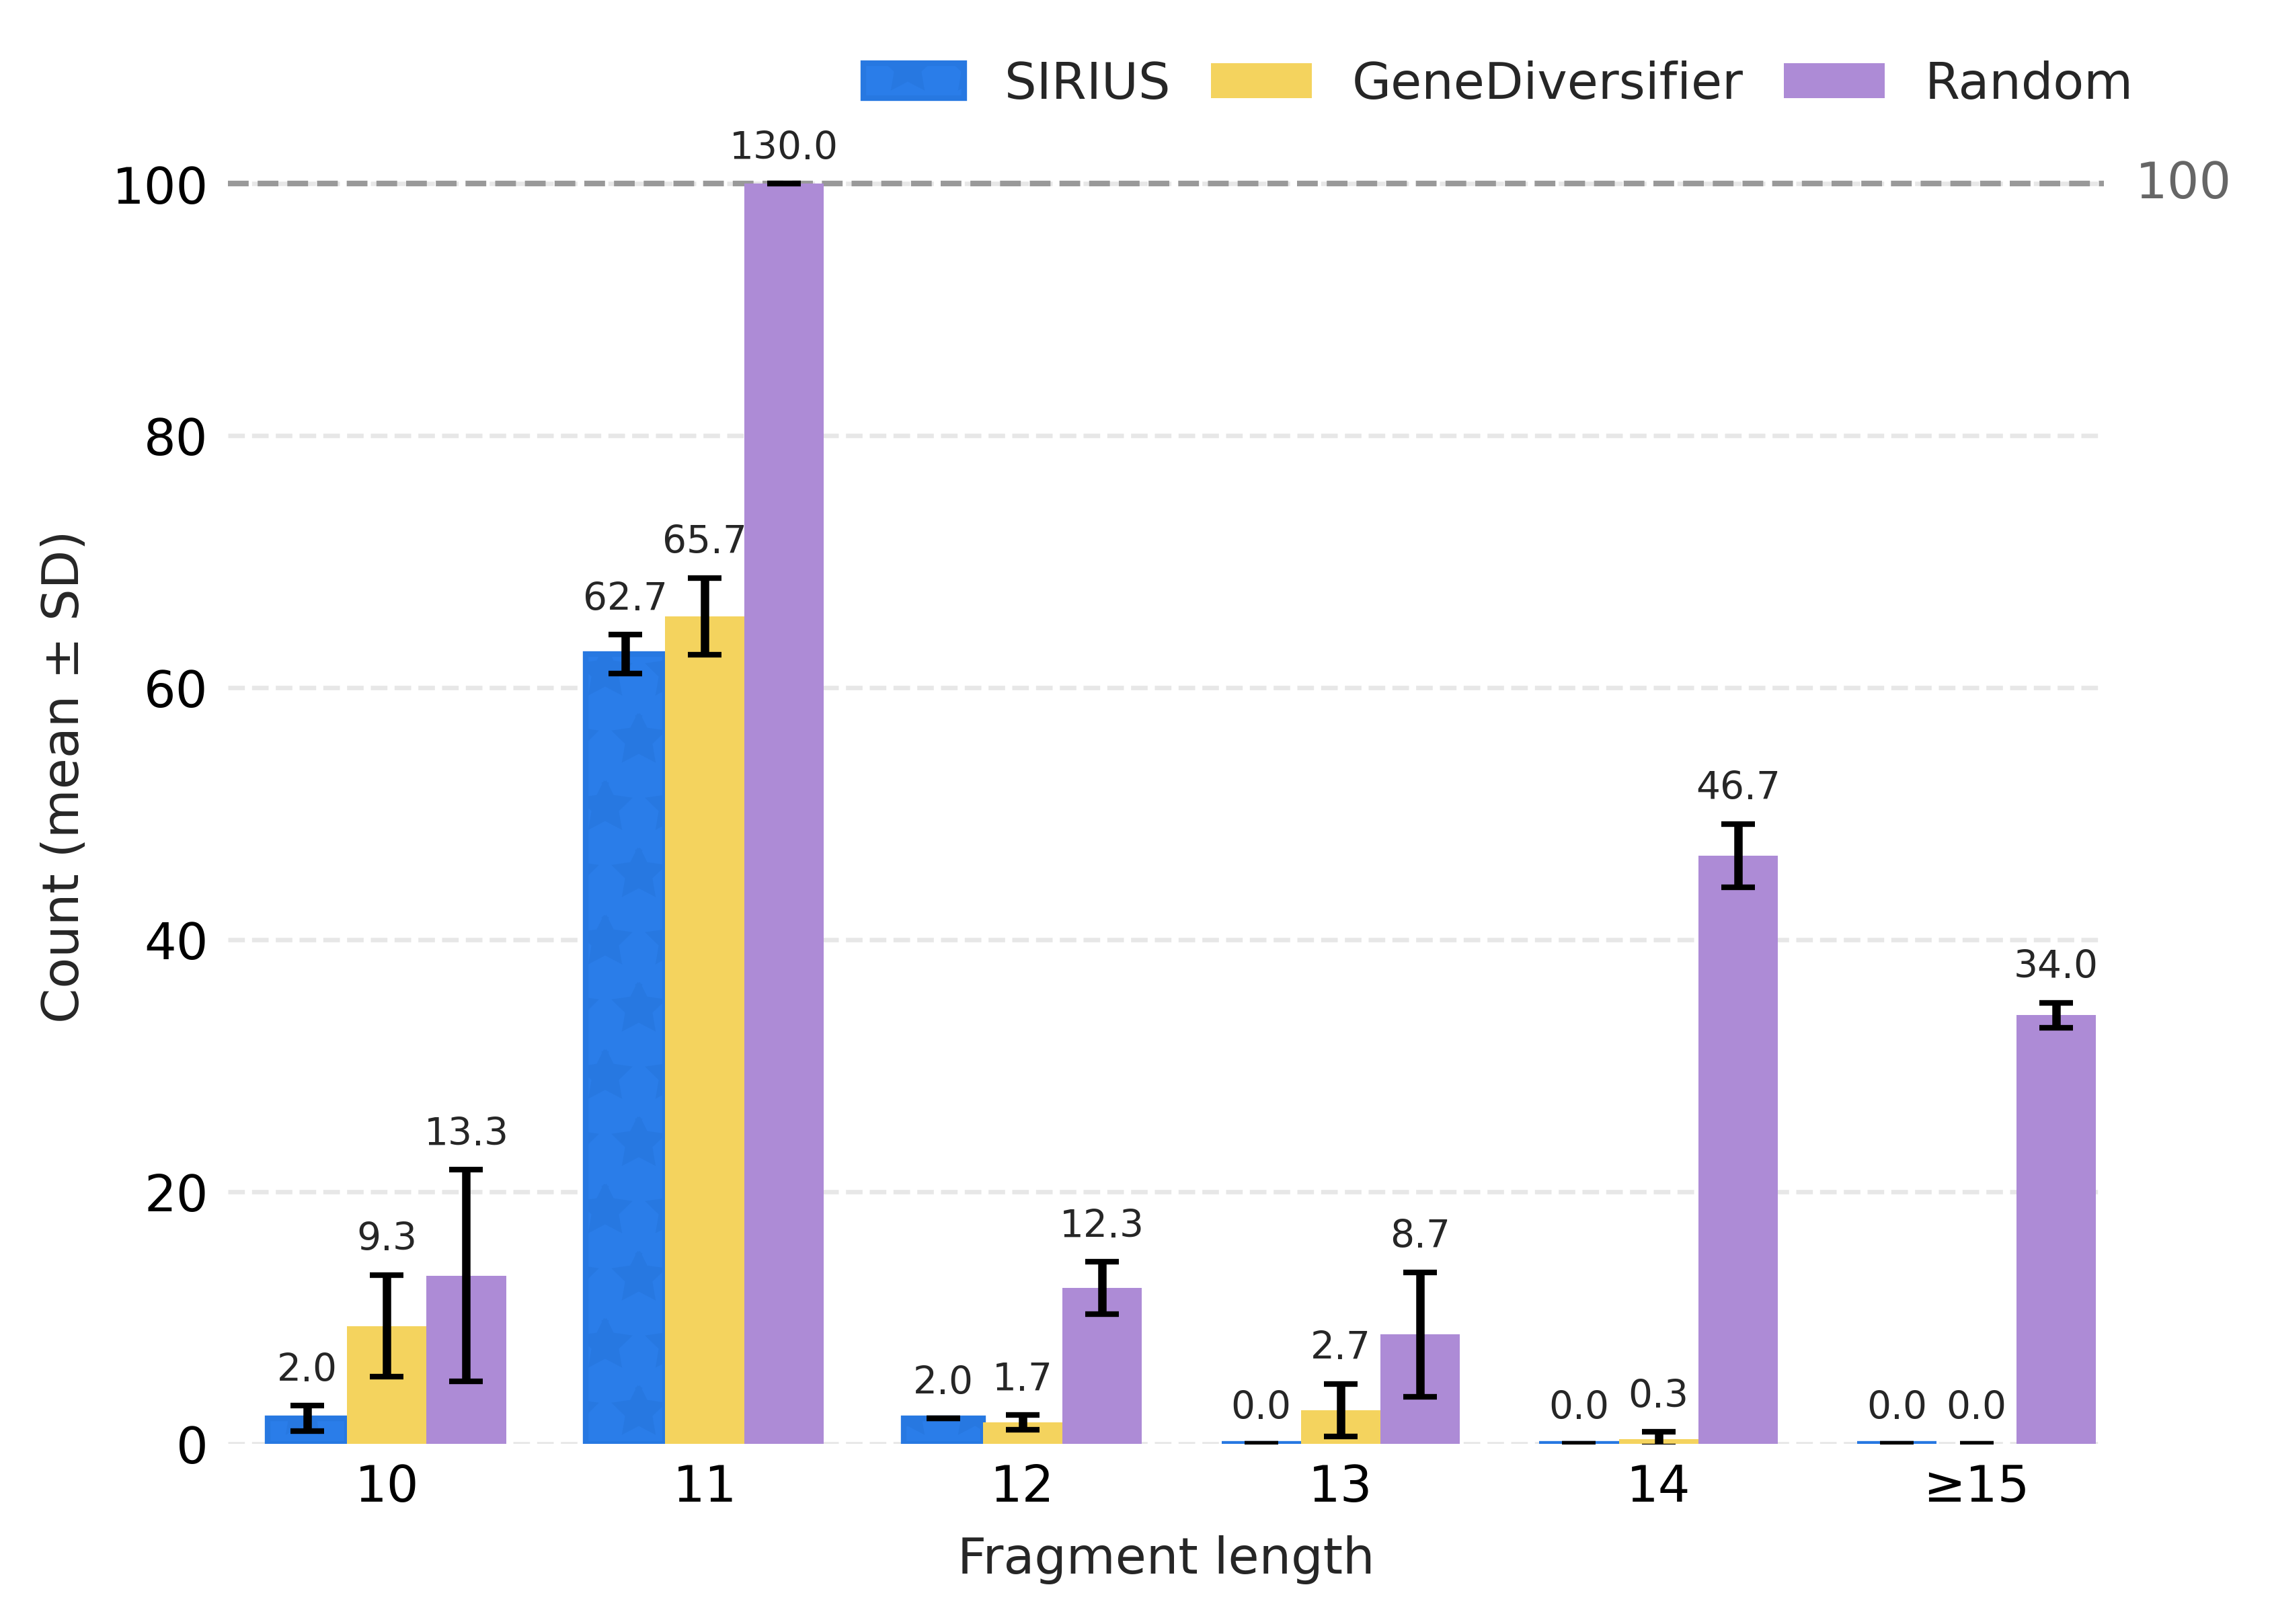

In [26]:
sirius_inputs = [
    "SRS/INFA2/length_counts_2025-11-03_17-16-10.txt",
    "SRS/INFA2_1/length_counts_2025-11-03_18-36-41.txt",
    "SRS/INFA2_2/length_counts_2025-11-03_19-57-02.txt"
]
gd_inputs = [
    "GD/gd_output_INFA2_1.txt",
    "GD/gd_output_INFA2_2.txt",
    "GD/gd_output_INFA2_3.txt",
]
random_inputs = [
    "RANDOM/random_INFA2_1.txt",
    "RANDOM/random_INFA2_2.txt",
    "RANDOM/random_INFA2_3.txt",
]

thresholds = [10, 11, 12, 13, 14, 15]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 6.8, "INFA2")

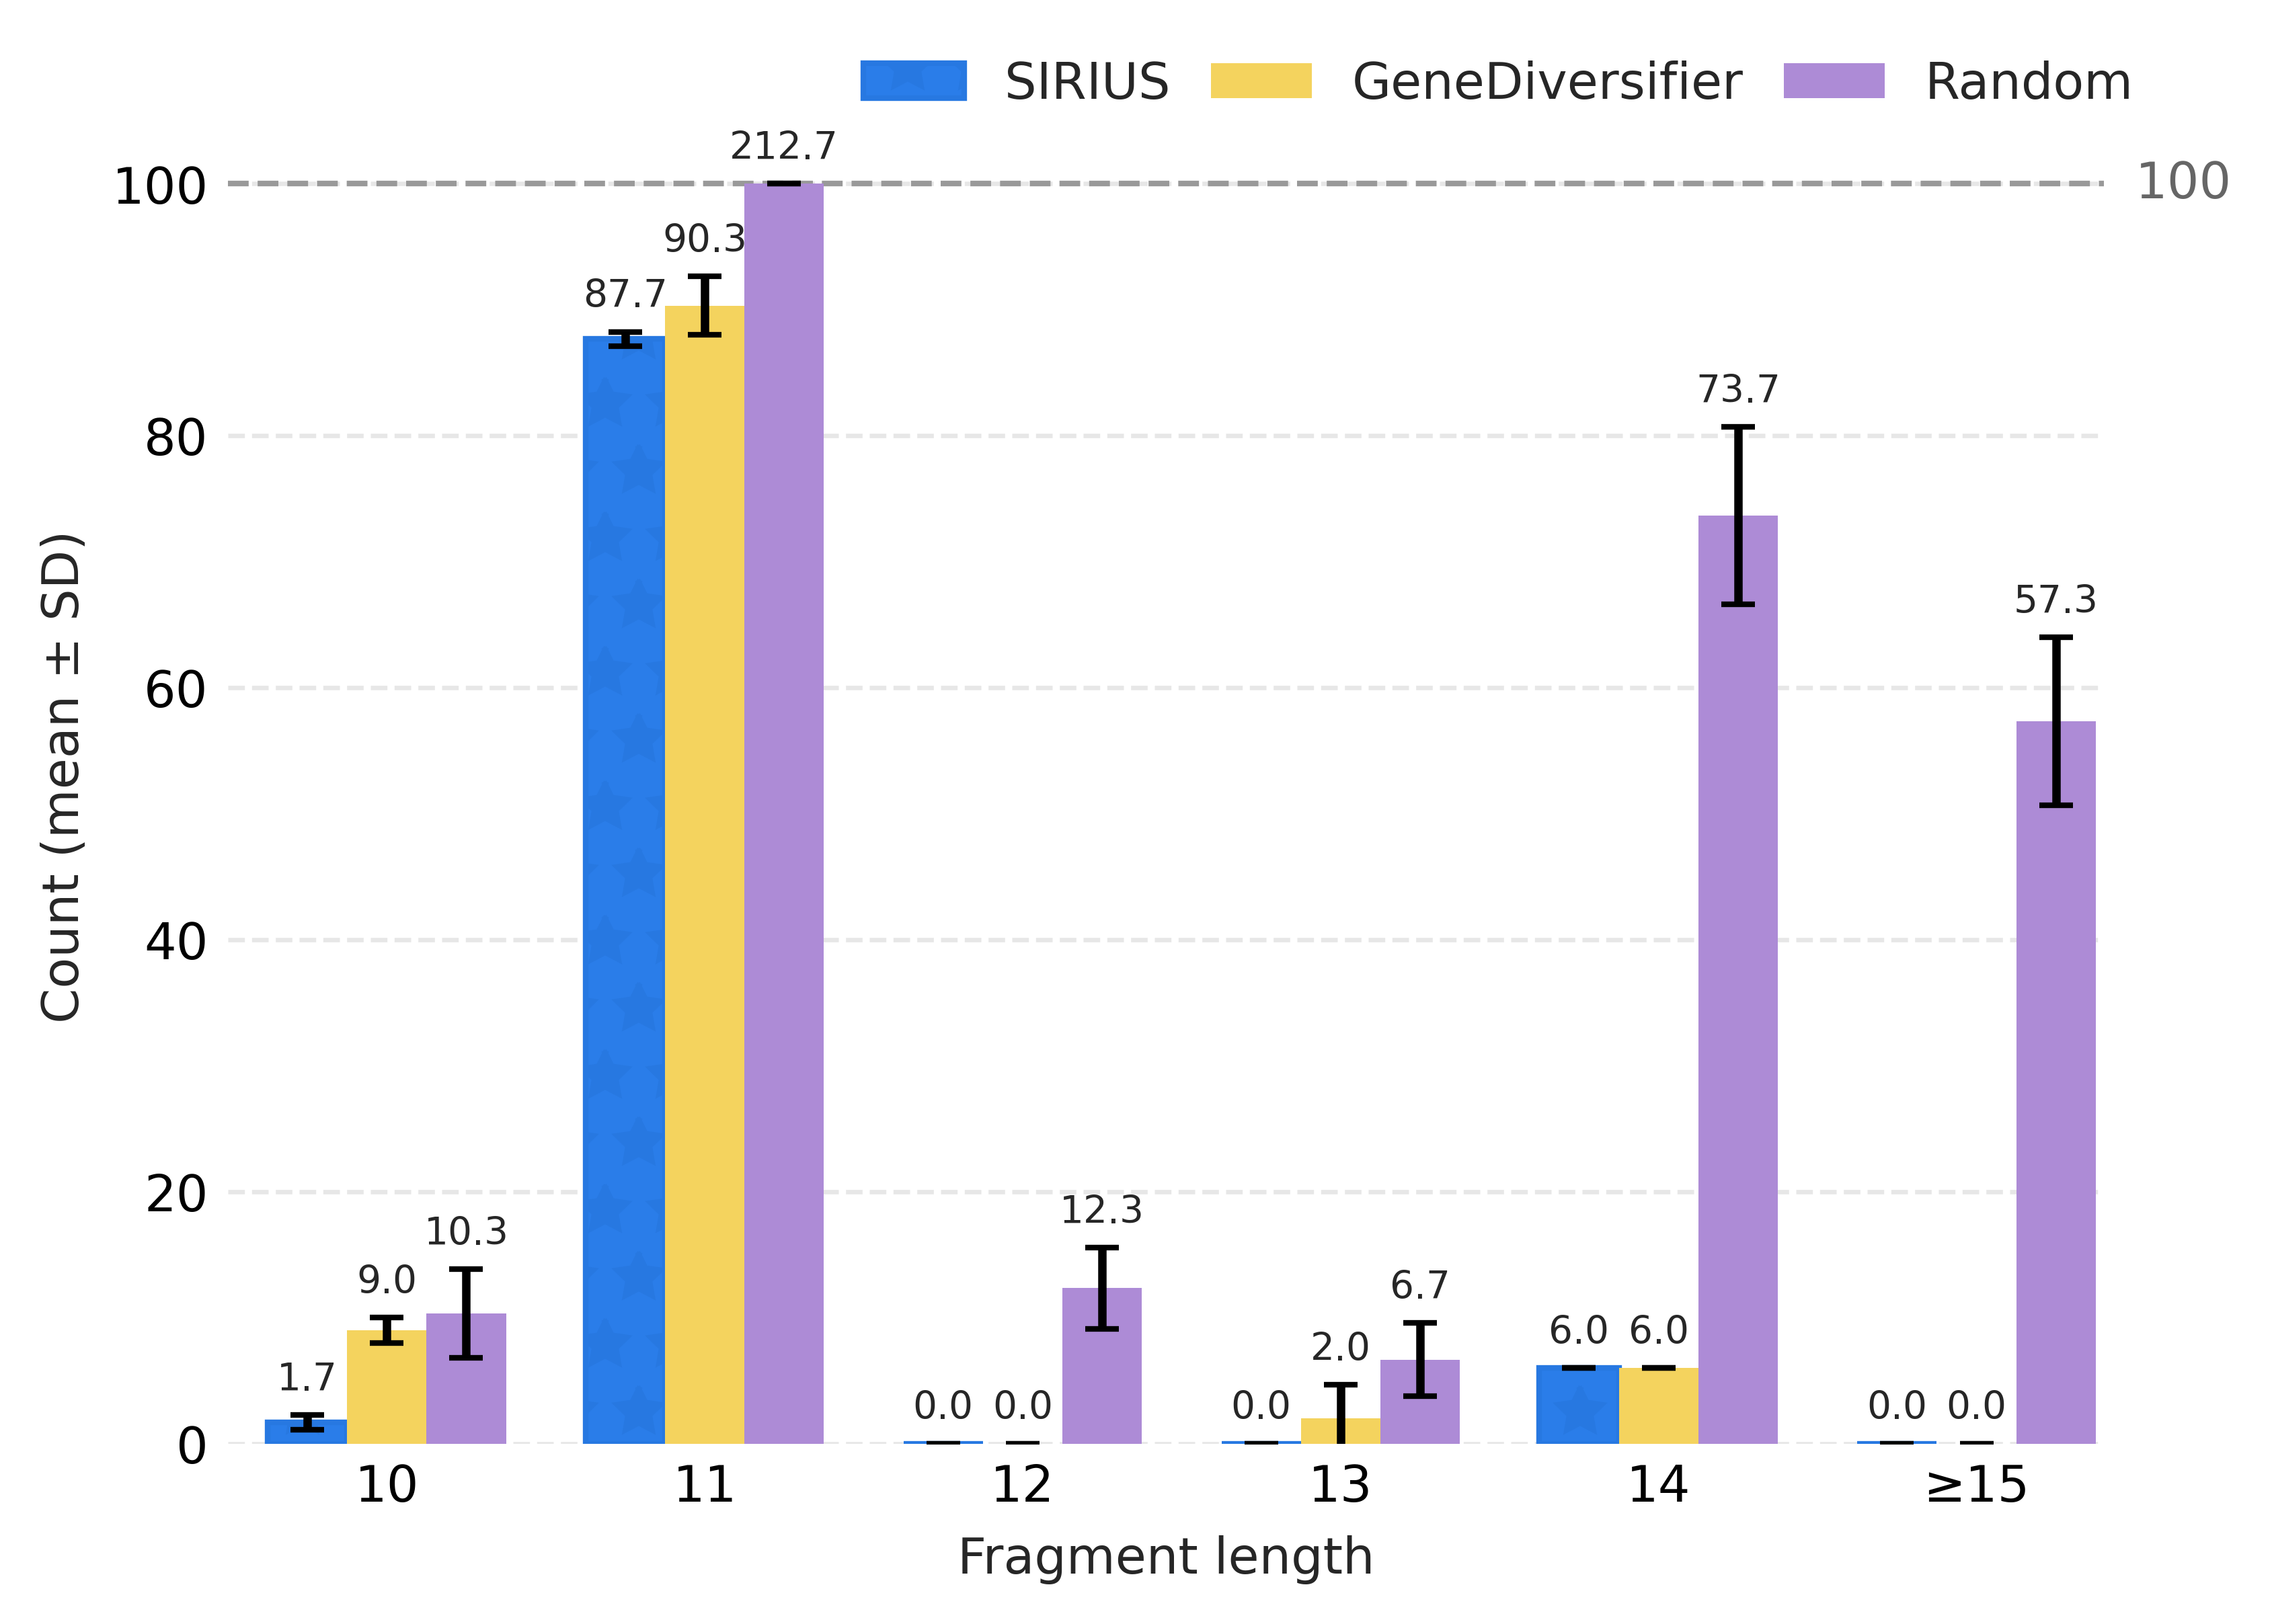

In [27]:
sirius_inputs = [
    "SRS/mCitrine/length_counts_2025-11-04_17-24-56.txt",
    "SRS/mCitrine_1/length_counts_2025-11-04_18-45-31.txt",
    "SRS/mCitrine_2/length_counts_2025-11-04_20-06-08.txt"
]
gd_inputs = [
    "GD/gd_output_mCitrine_1.txt",
    "GD/gd_output_mCitrine_2.txt",
    "GD/gd_output_mCitrine_3.txt",
]
random_inputs = [
    "RANDOM/random_mCitrine_1.txt",
    "RANDOM/random_mCitrine_2.txt",
    "RANDOM/random_mCitrine_3.txt",
]

thresholds = [10, 11, 12, 13, 14, 15]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 6.8, "mCitrine")

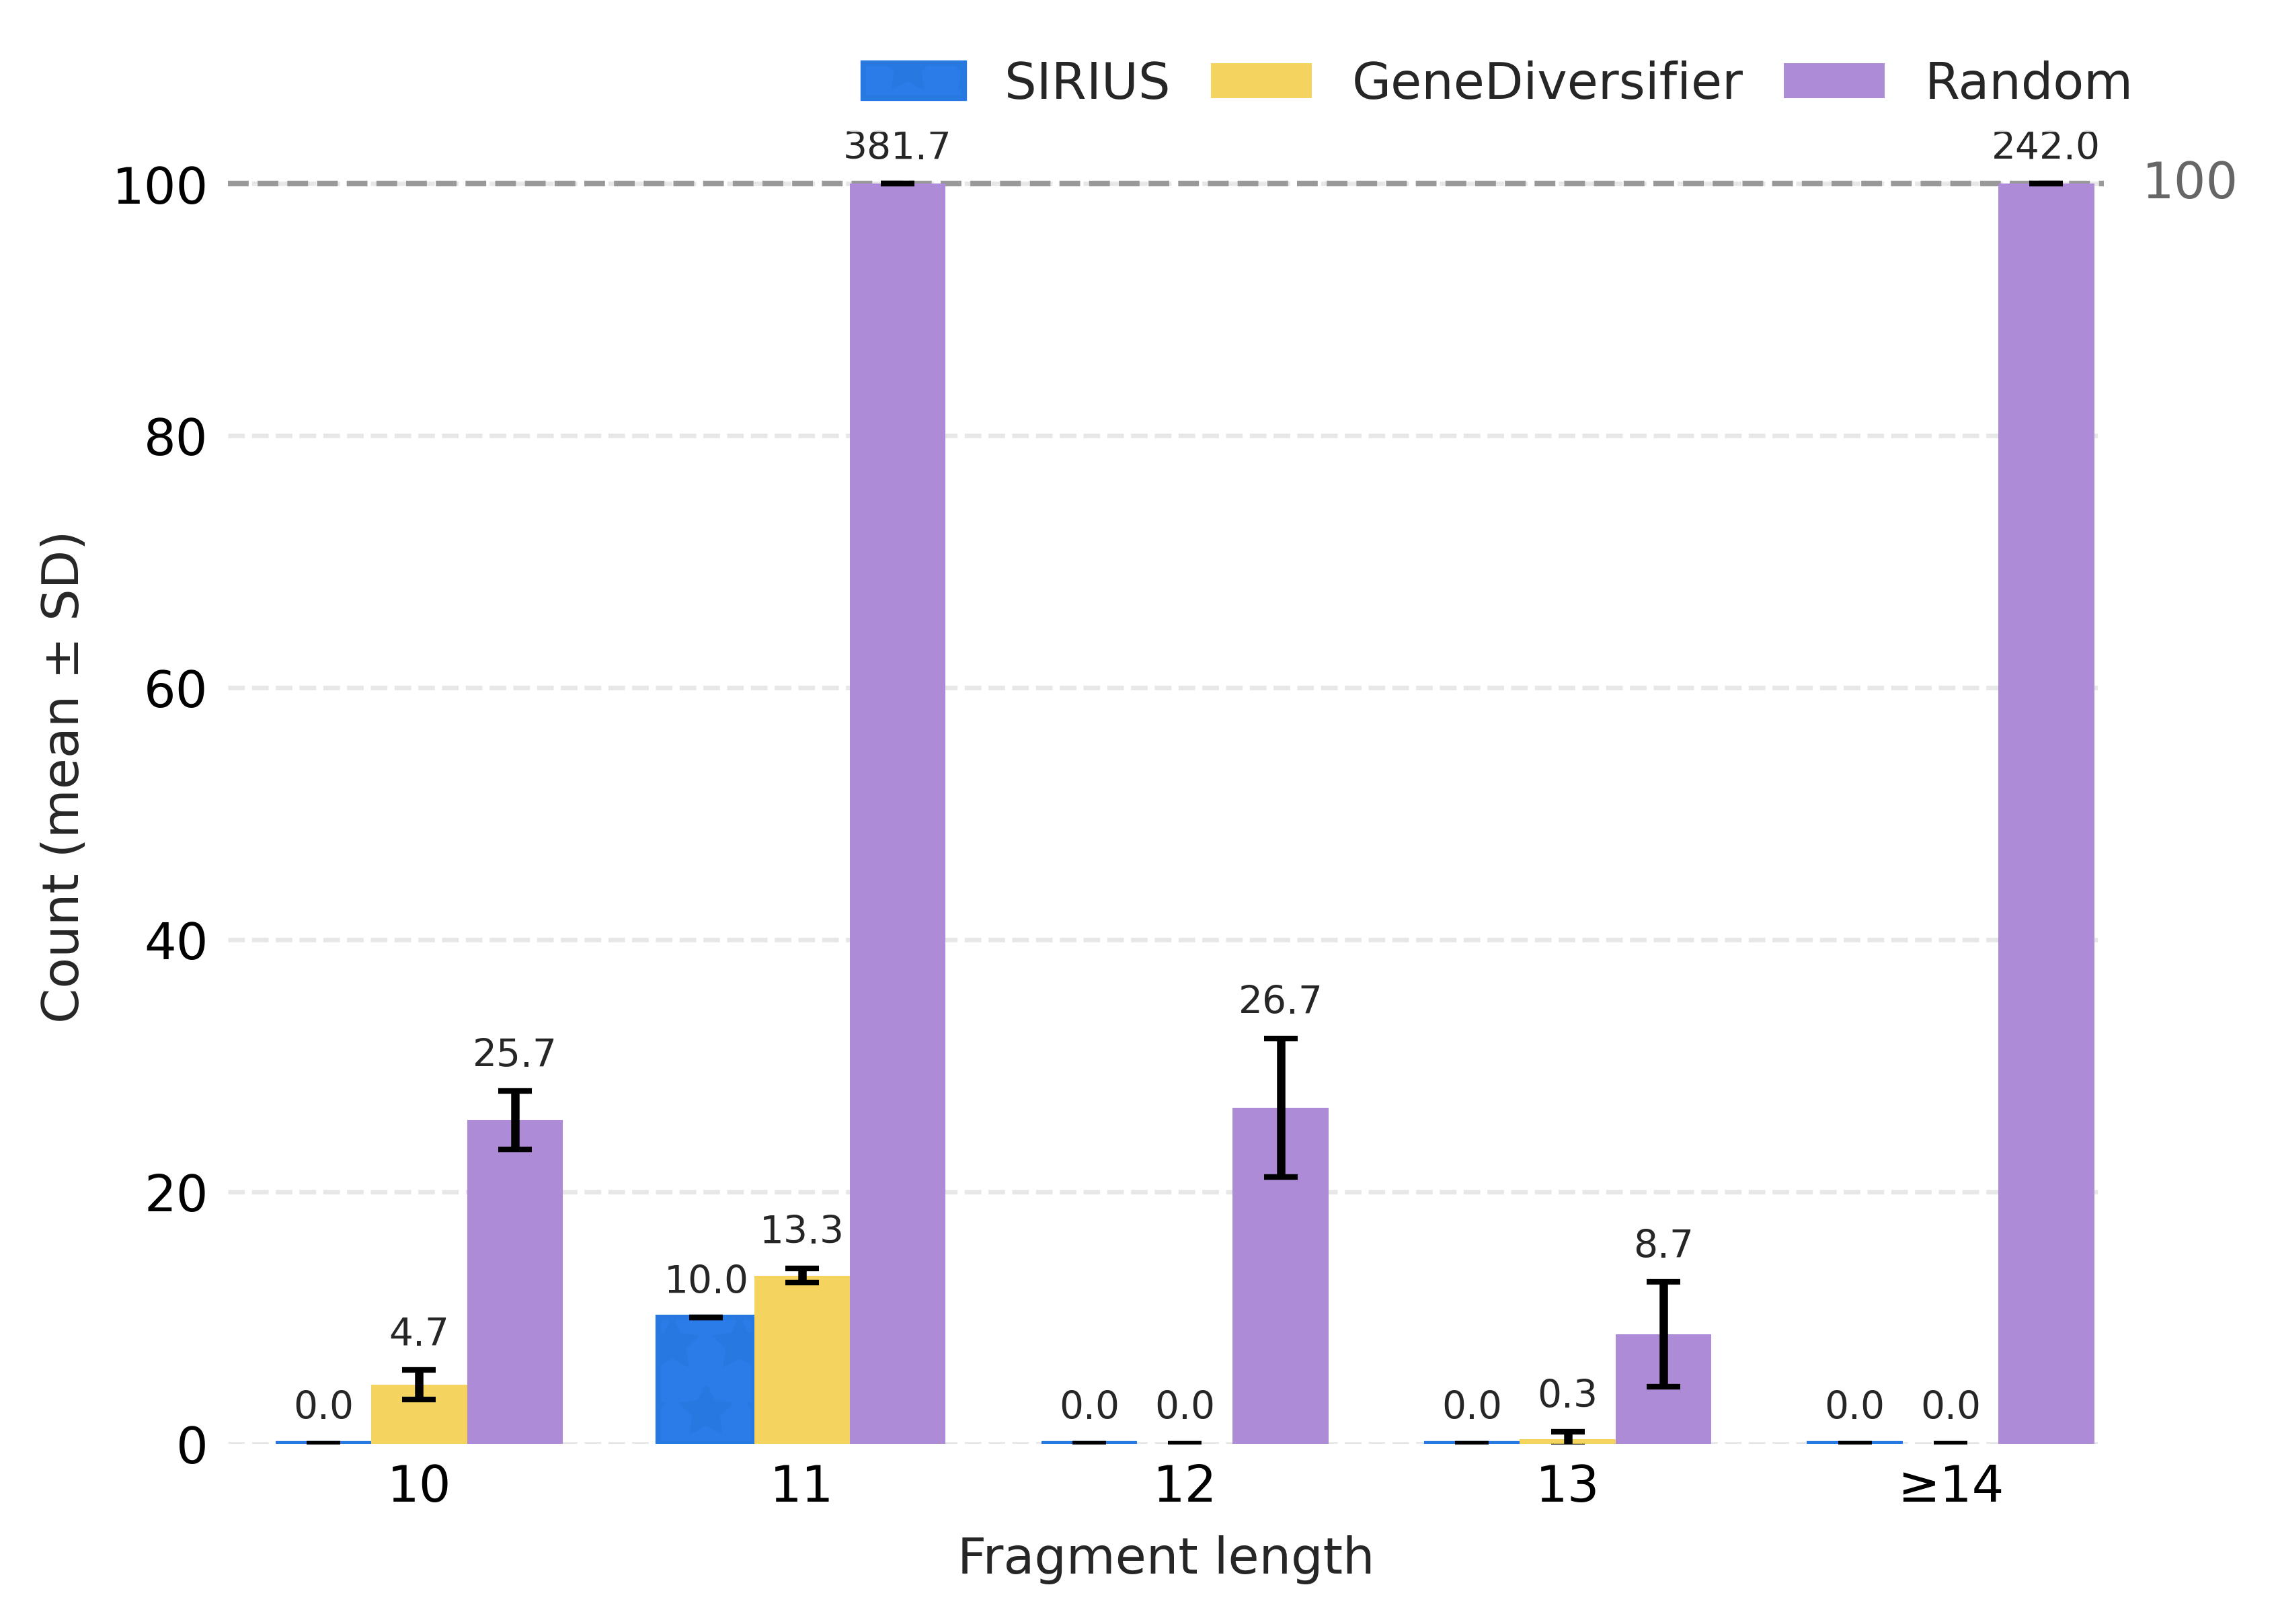

In [28]:
sirius_inputs = [
    "SRS/PLAT/length_counts_2025-11-04_05-20-28.txt",
    "SRS/PLAT_1/length_counts_2025-11-04_06-40-49.txt",
    "SRS/PLAT_2/length_counts_2025-11-04_08-01-12.txt"
]
gd_inputs = [
    "GD/gd_output_PLAT_1.txt",
    "GD/gd_output_PLAT_2.txt",
    "GD/gd_output_PLAT_3.txt",
]
random_inputs = [
    "RANDOM/random_PLAT_1.txt",
    "RANDOM/random_PLAT_2.txt",
    "RANDOM/random_PLAT_3.txt",
]

thresholds = [10, 11, 12, 13, 14]

paint_a_picture(sirius_inputs, gd_inputs, random_inputs, thresholds, 6.8, "PLAT")

In [29]:
mem_dict = dict()

srs_paths = []
for i in range(1, 10):
    srs_paths.append(f"memory/sirius_out_{i}")

i = 2
for p in srs_paths:
    files = os.listdir(p)
    file = [file for file in files if file.startswith("measurements")][0]

    with open(os.path.join(p, file), 'r') as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("peak_memory_mb"):
                mem_mb = int(line.split("=")[1].strip()) / 1000
                if mem_mb < 1:
                    mem_mb = 1
                mem_mb = float("%.2f" % round(mem_mb, 2))

                mem_dict[i] = mem_mb
    i+=1

mem_dict

{2: 1.0,
 3: 4.37,
 4: 23.11,
 5: 54.74,
 6: 87.53,
 7: 130.62,
 8: 183.38,
 9: 265.35,
 10: 387.08}

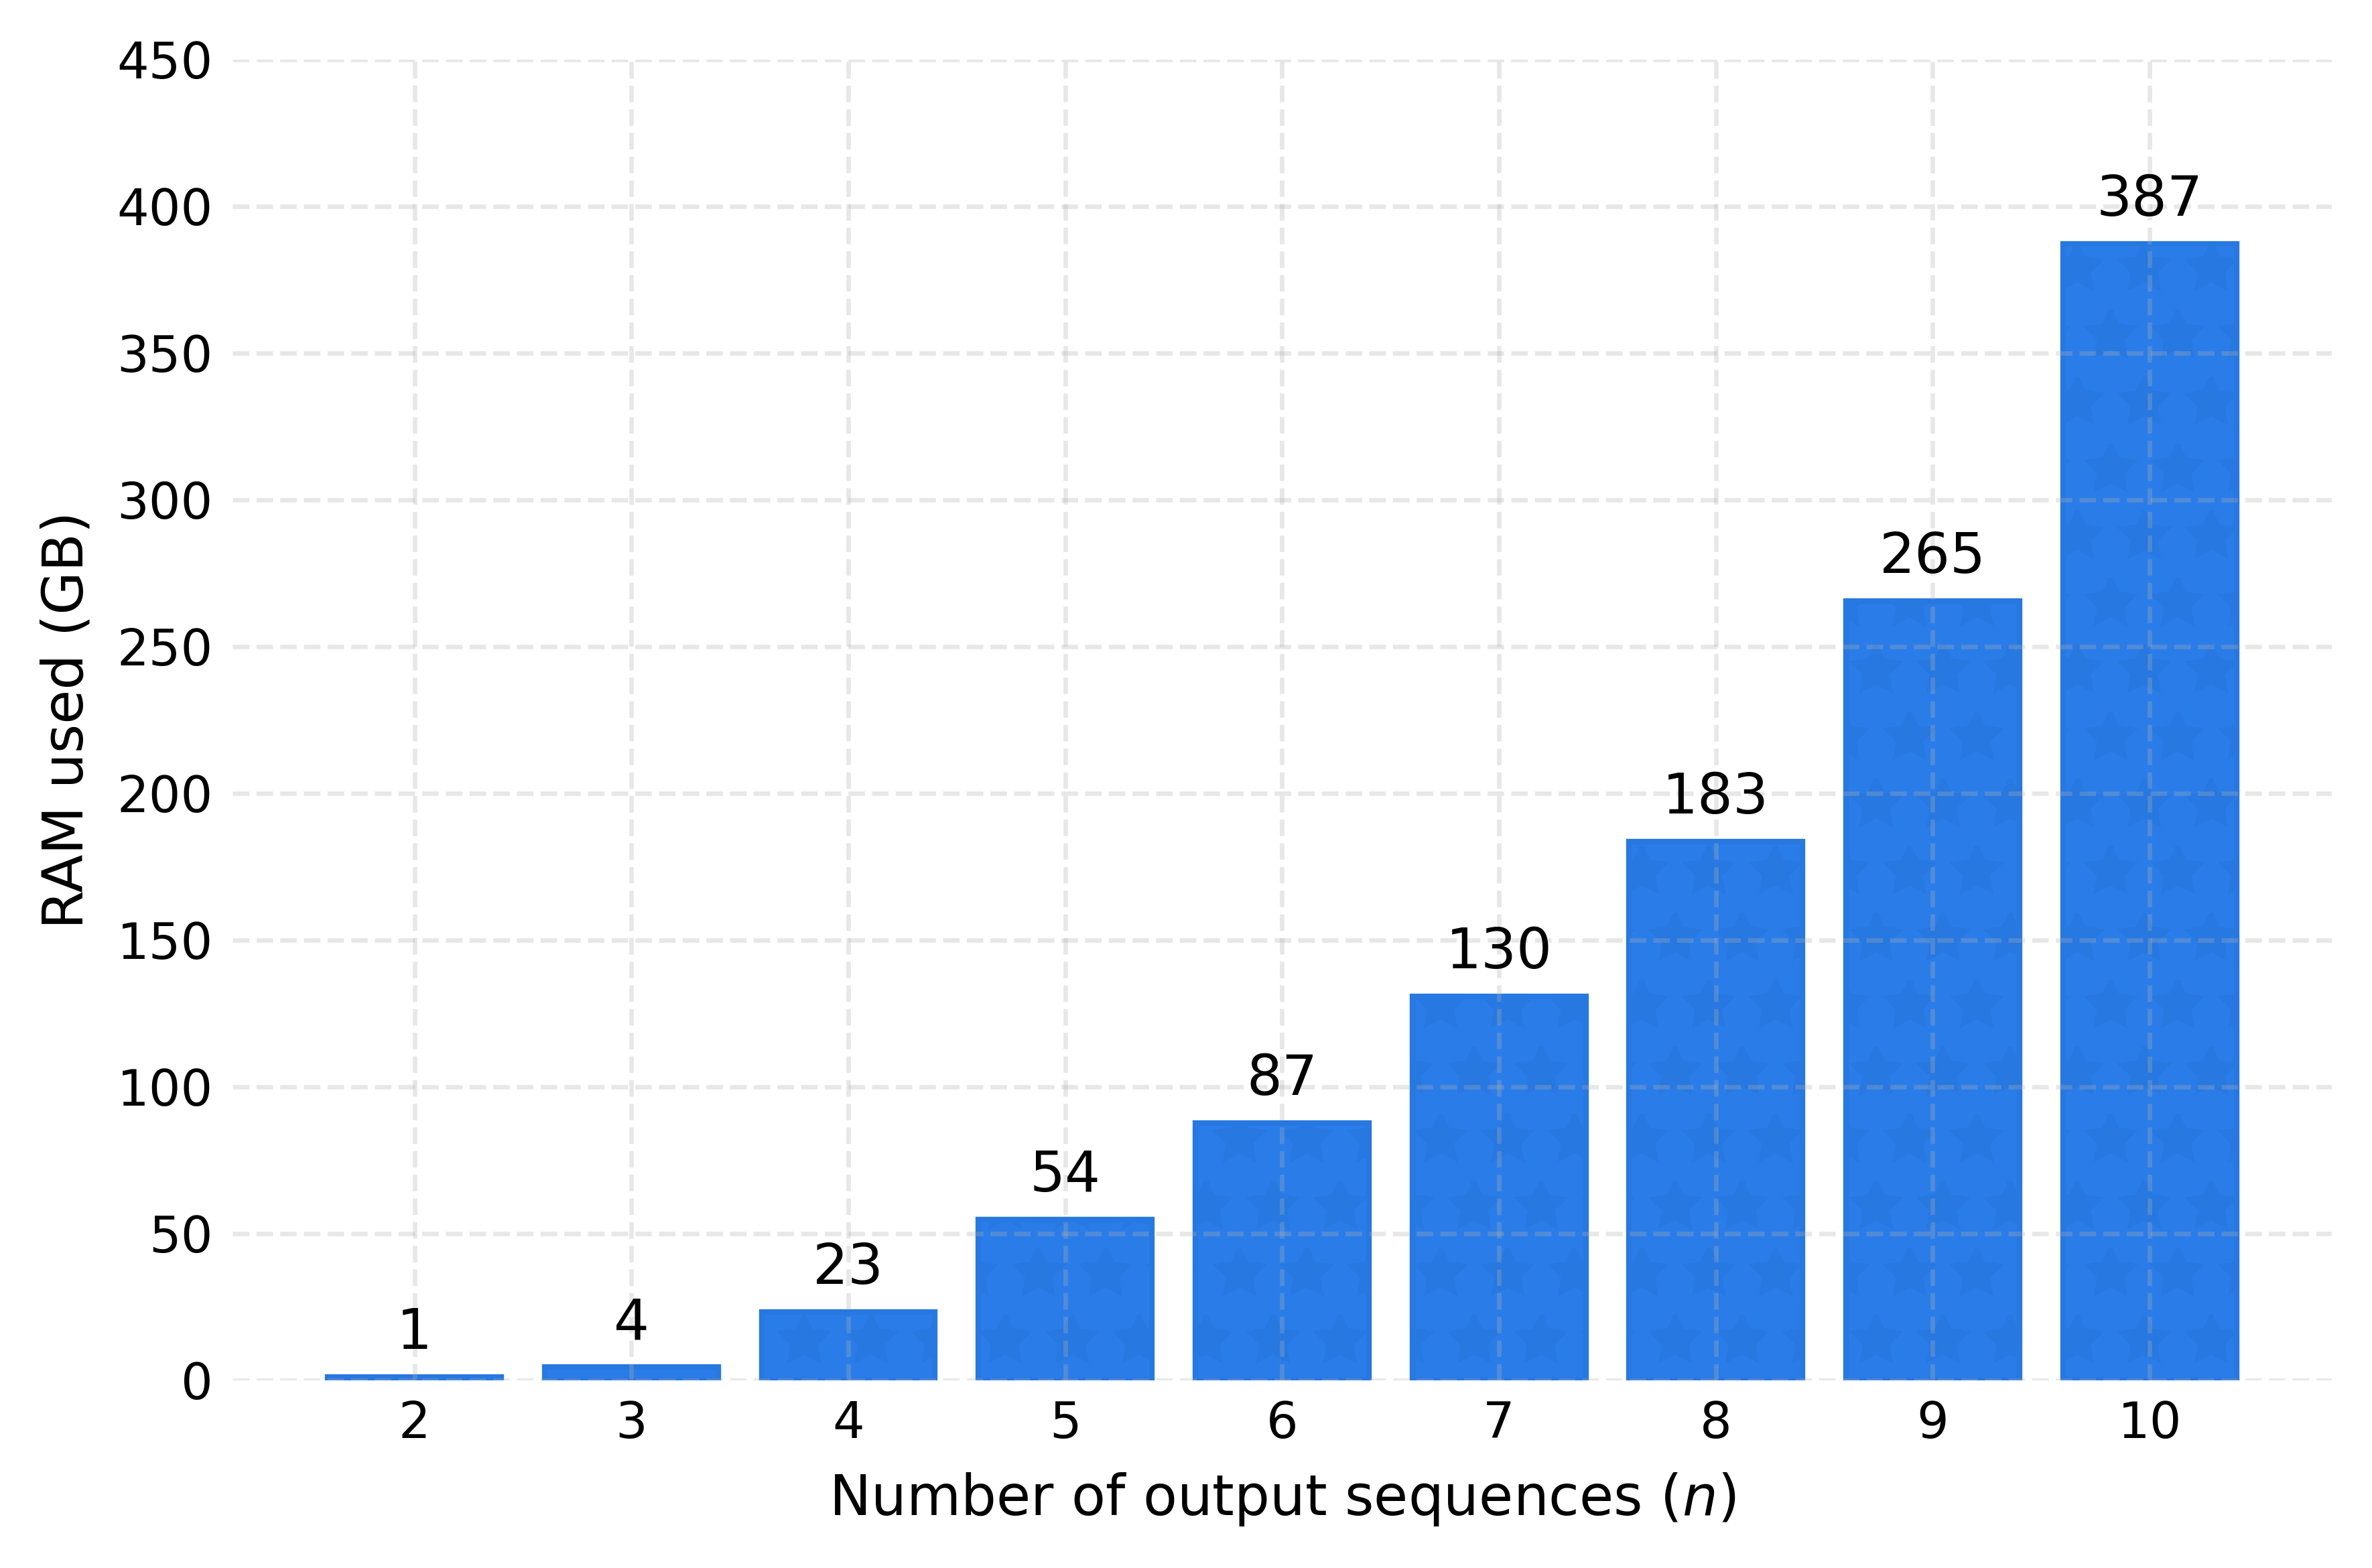

In [30]:
x = mem_dict.keys()
y = mem_dict.values()

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(x, y, color=siriusblue, hatch='*', edgecolor="#2778e1",)

def annotate_bars(ax, bars, values, fontsize=10, color="black", eps=0.02):
    ymax = ax.get_ylim()[1]
    top = max([b.get_height() for b in bars] + [1])
    headroom = max(2, 0.06 * top)
    ax.set_ylim(0, top + headroom)  # ensure space for labels

    for rect, v in zip(bars, values):
        h = rect.get_height()
        y = h if h > 0 else eps  # nudge zero-height bars up a bit
        ax.annotate(
            f"{int(v)}",
            xy=(rect.get_x() + rect.get_width() / 2.0, y),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=fontsize, color=color, clip_on=False
        )

annotate_bars(ax, bars, y)
ax.set_ylim(0, 450)
ax.set_xticks(np.arange(2, 11))
ax.set_xlabel('Number of output sequences ($\it{n}$)')
ax.set_ylabel('RAM used (GB)')
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax.grid(alpha=0.3, linestyle='--')
ax.tick_params(axis='both', which='both', length=0, labelsize=fontsize)
disable_ax_spines(ax)

fig.tight_layout()
plt.savefig("memory.pdf", bbox_inches='tight')